<font size="3">**Tarea 2 - Matias Rocha Ayala - 2022431515**</font>

<u> *Instrucciones* </u>

Los resultados de los ejericicios propuestos se deben entregar como un notebook por correo electronico a *juancaros@udec.cl* el dia 25/5 hasta las 21:00. Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion. 

El archivo a utilizar es *dataset_prueba.csv*, que contiene un conjunto de variables a nivel de ciudad durante el periodo de COVID-19, incluyendo caracteristicas sociodemograficas, movilidad, restricciones gubernamentales, casos de COVID-19, movilidad y busquedas en Google para terminos espeficicos.
**Variable dictionary**

    - "iso_code": "Country or region code",
    - "date": "Date of the record",
    - "retail_and_recreation_percent_change_from_baseline": "Change in retail/recreation activity",
    - "grocery_and_pharmacy_percent_change_from_baseline": "Change in grocery/pharmacy activity",
    - "parks_percent_change_from_baseline": "Change in park visits",
    - "transit_stations_percent_change_from_baseline": "Change in transit station activity",
    - "workplaces_raw": "Raw workplace activity data",
    - "residential_percent_change_from_baseline": "Change in residential activity",
    - "trend": "Trend indicator",
    - "workplaces": "Processed workplace activity data",
    - "Valor_Stringency_Index": "Stringency index value",
    - "Valor_GovernmentResponseIndex": "Government response index value",
    - "Valor_EconomicSupportIndex": "Economic support index value",
    - "Valor_Containment_Health_index": "Containment and health index value",
    - "workplace_closing": "Workplace closing indicator",
    - "daily_cases": "Daily reported cases",
    - "week": "Week number",
    - "year": "Year",
    - "CODE": "Region code",
    - "NAME": "Region name",
    - "Population": "Population of the region",
    - "agriculture": "Agriculture sector data",
    - "industry": "Industry sector data",
    - "construction": "Construction sector data",
    - "age_dependency": "Age dependency ratio",
    - "old_age_dependency": "Old age dependency ratio",
    - "young_age_dependency": "Young age dependency ratio",
    - "sex_ratio": "Sex ratio",
    - "unemp": "Unemployment rate",
    - "f_unemp": "Female unemployment rate",
    - "m_unemp": "Male unemployment rate",
    - "foreigners": "Foreign population percentage",
    - "country": "Country name"


## Configuración del Entorno

Importamos las librerías necesarias para el análisis.

In [1]:
# Librerías estándar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import missingno as msno

from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects
import statsmodels.api as sm
from scipy import stats

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')



---
### 1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 

<Axes: >

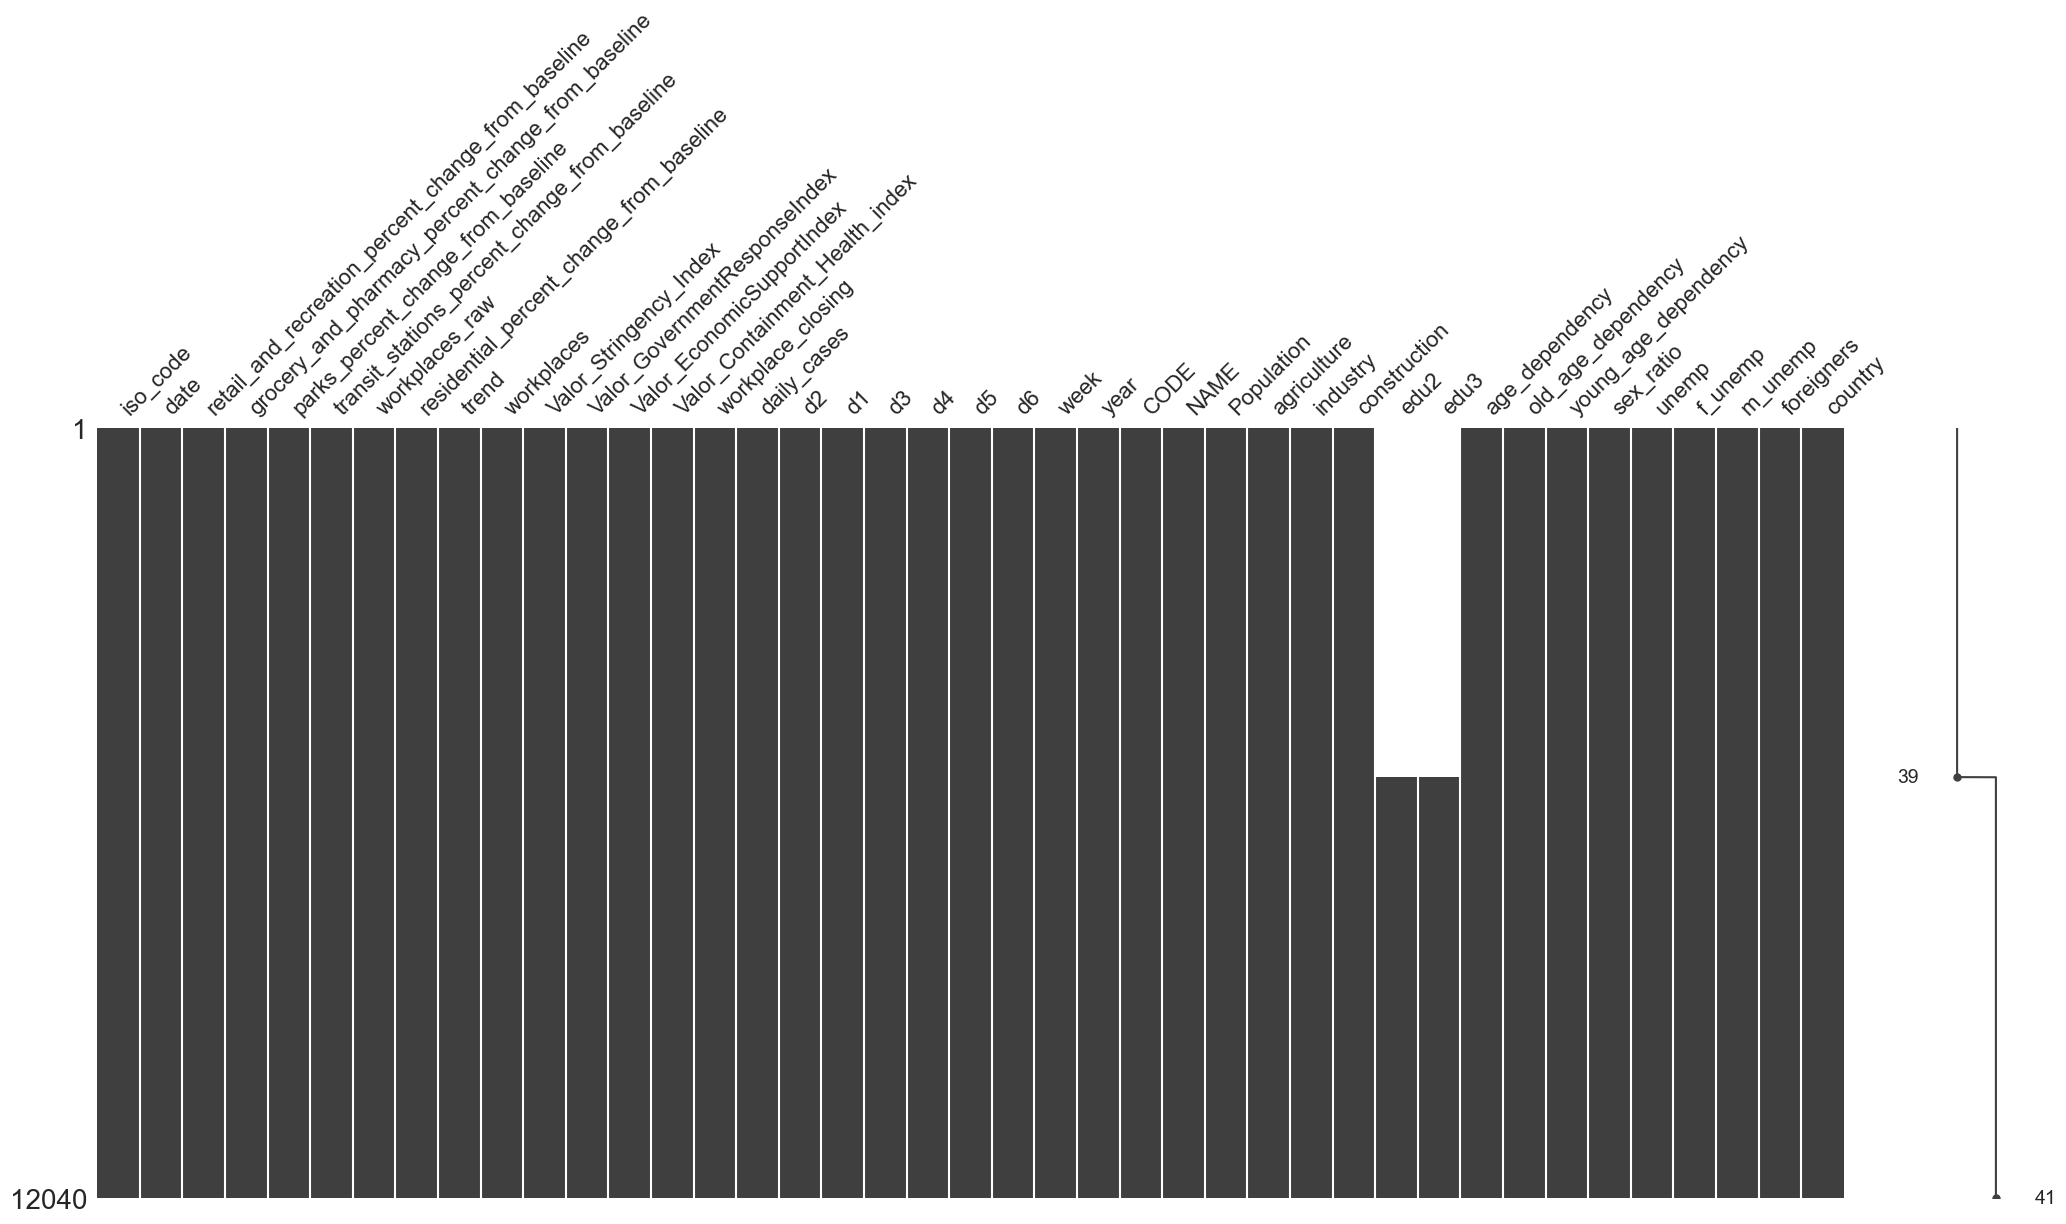

In [2]:
# Cargar el dataset
df = pd.read_csv('data/dataset_prueba.csv')
msno.matrix(df)

### 1.1 Identificación de tipos de datos

In [3]:
# Tipos de datos de cada columna
print(df.dtypes)
print(f'\n--- Resumen de tipos ---')
print(df.dtypes.value_counts())

iso_code                                               object
date                                                   object
retail_and_recreation_percent_change_from_baseline    float64
grocery_and_pharmacy_percent_change_from_baseline     float64
parks_percent_change_from_baseline                    float64
transit_stations_percent_change_from_baseline         float64
workplaces_raw                                        float64
residential_percent_change_from_baseline              float64
trend                                                 float64
workplaces                                            float64
Valor_Stringency_Index                                float64
Valor_GovernmentResponseIndex                         float64
Valor_EconomicSupportIndex                            float64
Valor_Containment_Health_index                        float64
workplace_closing                                     float64
daily_cases                                           float64
d2      

### 1.2 Estadísticas descriptivas

In [4]:
# Seleccionar variables numéricas clave para estadísticas descriptivas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Variables principales de interés
key_vars = [
    'workplaces', 'workplaces_raw',
    'Valor_Stringency_Index', 'Valor_GovernmentResponseIndex',
    'Valor_EconomicSupportIndex', 'Valor_Containment_Health_index',
    'workplace_closing', 'daily_cases',
    'retail_and_recreation_percent_change_from_baseline',
    'grocery_and_pharmacy_percent_change_from_baseline',
    'parks_percent_change_from_baseline',
    'transit_stations_percent_change_from_baseline',
    'residential_percent_change_from_baseline',
    'Population', 'unemp', 'age_dependency', 'sex_ratio', 'foreigners'
]

# Filtrar solo las que existen
key_vars = [v for v in key_vars if v in df.columns]
df[key_vars].describe().round(4).T

,count,mean,std,min,25%,50%,75%,max
workplaces,12040.0,-18.6674,11.8014,-76.7871,-24.3584,-16.8200,-10.8840,19.0576
workplaces_raw,12040.0,-25.0029,14.6811,-87.0000,-32.4000,-22.8000,-14.4000,6.6000
Valor_Stringency_Index,12040.0,27.4863,29.8359,0.0000,0.0000,15.8580,53.4200,93.5200
Valor_GovernmentResponseIndex,12040.0,30.6368,30.2449,0.0000,0.0000,32.0300,60.1600,81.3060
Valor_EconomicSupportIndex,12040.0,30.9551,36.3643,0.0000,0.0000,0.0000,75.0000,100.0000
Valor_Containment_Health_index,12040.0,30.5917,29.9431,0.0000,0.0000,36.6100,59.2300,85.4200
workplace_closing,12040.0,0.8508,0.9971,0.0000,0.0000,0.0000,2.0000,3.0000
daily_cases,12040.0,2355.7334,3154.9144,0.0000,0.0372,632.0104,3815.6444,22203.3142
retail_and_recreation_percent_change_from_baseline,12040.0,-16.4373,21.5994,-95.6000,-26.4000,-11.4000,-3.6000,74.6000
grocery_and_pharmacy_percent_change_from_baseline,12040.0,5.1243,15.7073,-66.2000,-3.2000,6.2000,15.0000,83.6000


### 1.3 Distribuciones de variables clave

Revisamos las distribuciones de la variable dependiente (`workplaces`) y las principales variables independientes de restricciones gubernamentales.

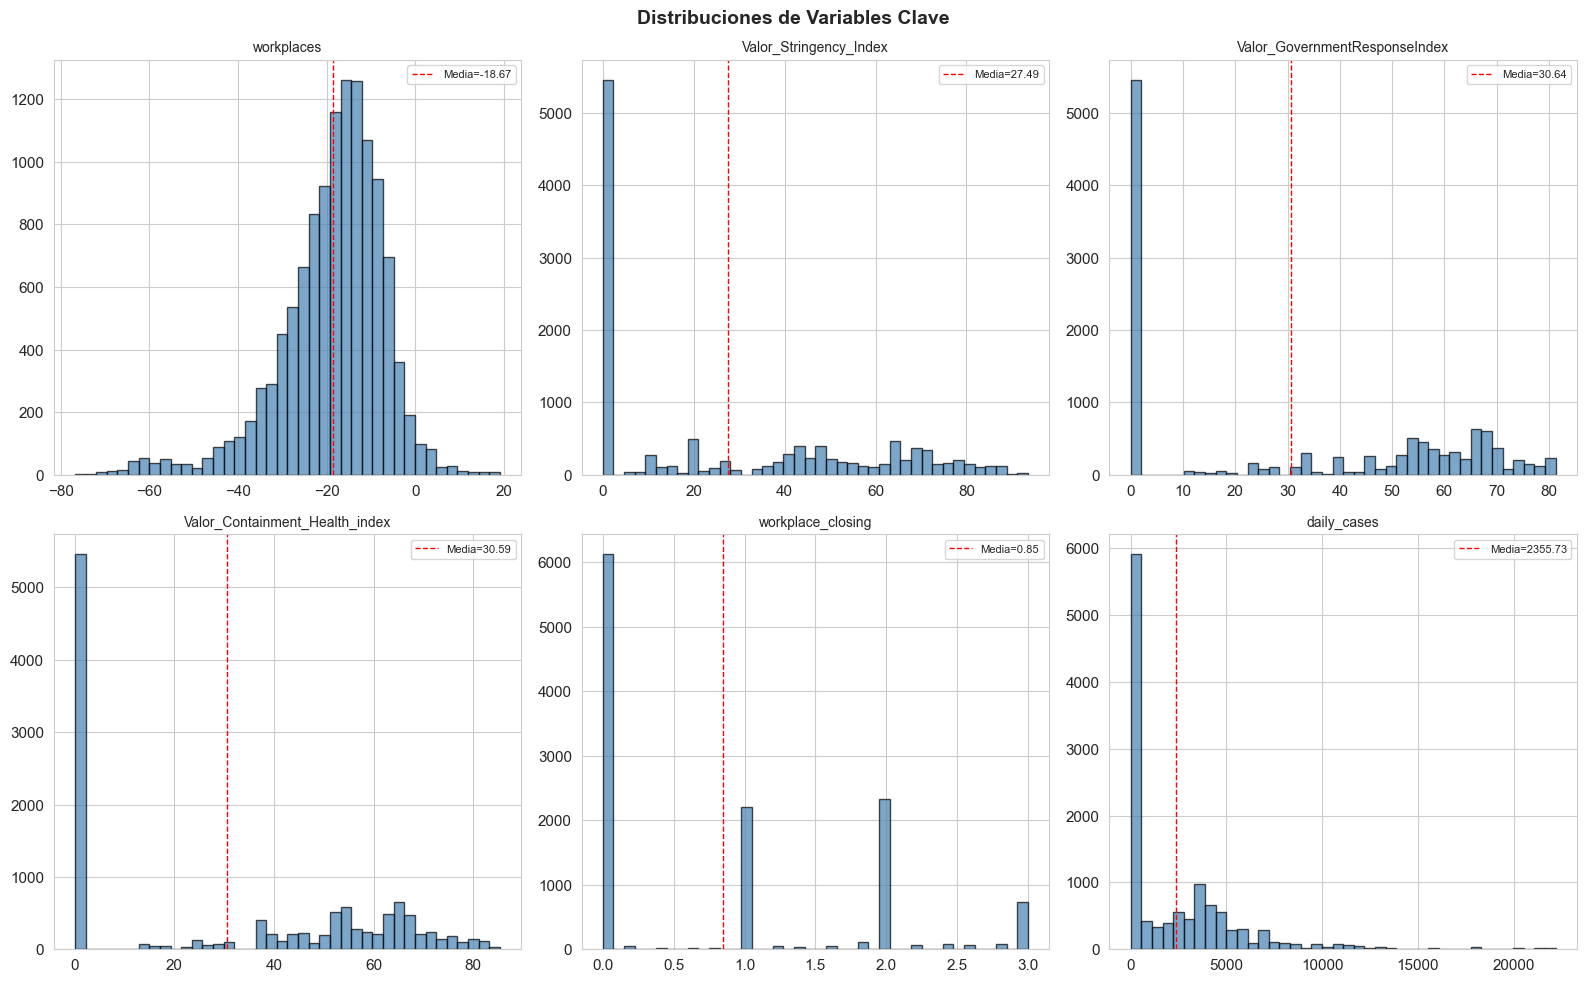

In [5]:
# Distribuciones de las variables más relevantes
vars_to_plot = [
    'workplaces', 'Valor_Stringency_Index', 
    'Valor_GovernmentResponseIndex', 'Valor_Containment_Health_index',
    'workplace_closing', 'daily_cases'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, var in enumerate(vars_to_plot):
    ax = axes[i // 3, i % 3]
    df[var].dropna().hist(bins=40, ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(var, fontsize=10)
    ax.axvline(df[var].mean(), color='red', linestyle='--', linewidth=1, label=f'Media={df[var].mean():.2f}')
    ax.legend(fontsize=8)

fig.suptitle('Distribuciones de Variables Clave', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

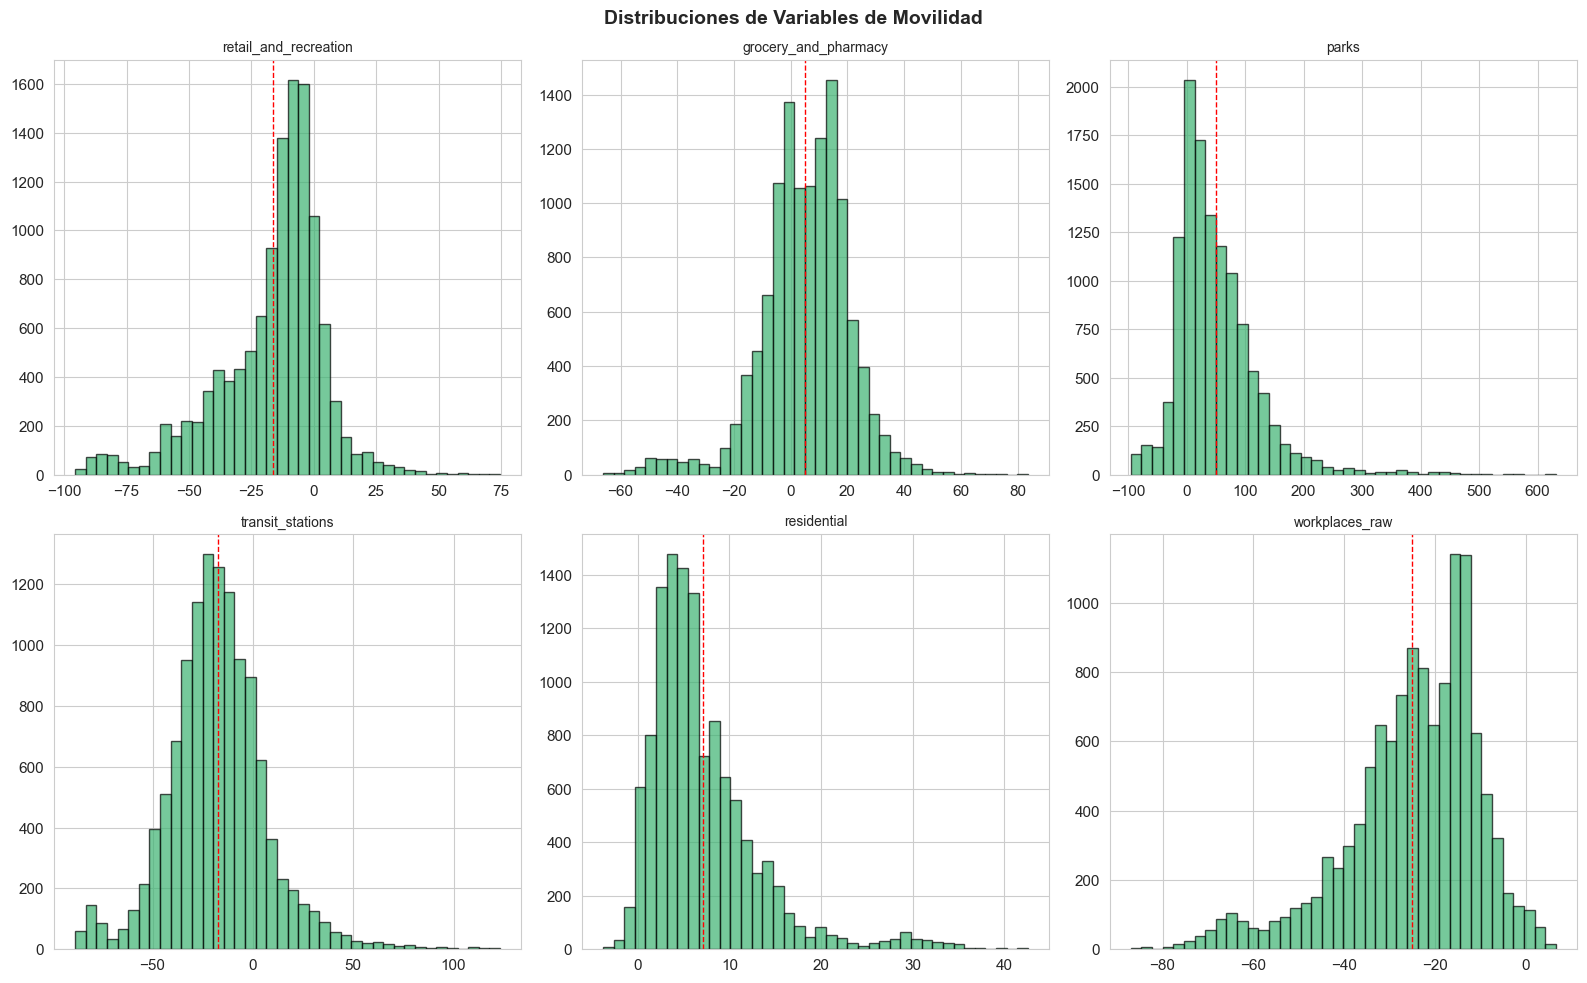

In [6]:
# Distribuciones de variables de movilidad
mobility_vars = [
    'retail_and_recreation_percent_change_from_baseline',
    'grocery_and_pharmacy_percent_change_from_baseline',
    'parks_percent_change_from_baseline',
    'transit_stations_percent_change_from_baseline',
    'residential_percent_change_from_baseline',
    'workplaces_raw'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, var in enumerate(mobility_vars):
    ax = axes[i // 3, i % 3]
    df[var].dropna().hist(bins=40, ax=ax, color='mediumseagreen', edgecolor='black', alpha=0.7)
    ax.set_title(var.replace('_percent_change_from_baseline', ''), fontsize=10)
    ax.axvline(df[var].mean(), color='red', linestyle='--', linewidth=1)

fig.suptitle('Distribuciones de Variables de Movilidad', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.4 Detección de Outliers

Utilizamos boxplots e IQR para identificar valores atípicos en las variables principales.

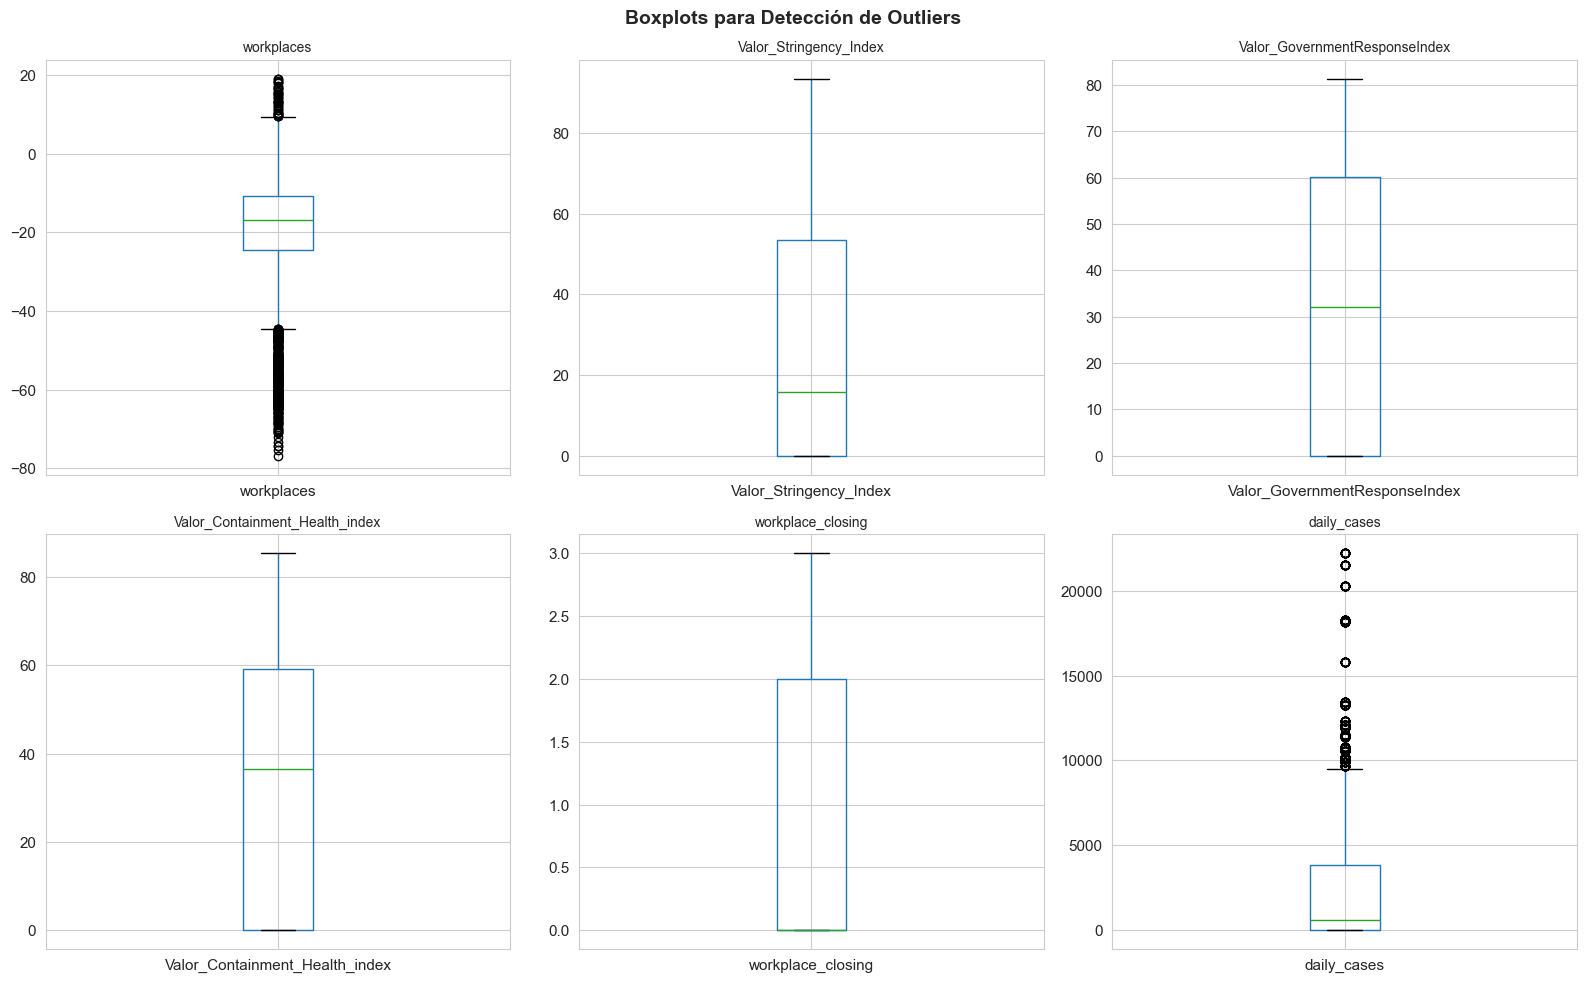

In [7]:
# Boxplots de variables clave
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, var in enumerate(vars_to_plot):
    ax = axes[i // 3, i % 3]
    df.boxplot(column=var, ax=ax)
    ax.set_title(var, fontsize=10)

fig.suptitle('Boxplots para Detección de Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Conteo de outliers
outlier_vars = ['workplaces', 'daily_cases', 'Valor_Stringency_Index', 
                'Valor_GovernmentResponseIndex', 'Valor_Containment_Health_index',
                'Population', 'unemp']

for var in outlier_vars:
    if var in df.columns:
        Q1 = df[var].quantile(0.25)
        Q3 = df[var].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[var] < lower) | (df[var] > upper)]
        pct = len(outliers) / len(df) * 100
        print(f'{var}: {len(outliers)} outliers ({pct:.1f}%) | Rango aceptable: [{lower:.2f}, {upper:.2f}]')

workplaces: 450 outliers (3.7%) | Rango aceptable: [-44.57, 9.33]
daily_cases: 425 outliers (3.5%) | Rango aceptable: [-5723.37, 9539.06]
Valor_Stringency_Index: 0 outliers (0.0%) | Rango aceptable: [-80.13, 133.55]
Valor_GovernmentResponseIndex: 0 outliers (0.0%) | Rango aceptable: [-90.24, 150.40]
Valor_Containment_Health_index: 0 outliers (0.0%) | Rango aceptable: [-88.84, 148.07]
Population: 1400 outliers (11.6%) | Rango aceptable: [-313.80, 1181.12]
unemp: 0 outliers (0.0%) | Rango aceptable: [-12.00, 36.00]


### 1.5 Limpieza de Datos

A continuación se realizan los pasos de limpieza necesarios basados en la exploración anterior.

In [9]:
# Conversión de la columna 'date' a formato datetime
df['date'] = pd.to_datetime(df['date'])

# verificar duplicados por (NAME, date)
n_dup = df.duplicated(subset=['NAME', 'date']).sum()
if n_dup > 0:
    df = df.drop_duplicates(subset=['NAME', 'date'], keep='first')
    
# Eliminar columnas edu2 y edu3 por alto porcentaje de datos faltantes
cols_to_drop = [col for col in ['edu2', 'edu3'] if col in df.columns]
if len(cols_to_drop) > 0:
    df = df.drop(columns=cols_to_drop)
   

In [10]:
# Resumen de ciudades y periodos en los datos limpios
print(f'Número de ciudades únicas: {df["NAME"].nunique()}')
print(f'Países representados: {df["country"].unique()}')
print(f'Periodo temporal: {df["date"].min()} a {df["date"].max()}')
print(f'Semanas por ciudad (promedio): {df.groupby("NAME")["week"].count().mean():.0f}')
print(f'\nCiudades por país:')
print(df.groupby('country')['NAME'].nunique())

Número de ciudades únicas: 86
Países representados: ['DE' 'ES' 'FR' 'IT' 'SE']
Periodo temporal: 2020-02-17 00:00:00 a 2022-10-17 00:00:00
Semanas por ciudad (promedio): 140

Ciudades por país:
country
DE    39
ES    16
FR    15
IT    14
SE     2
Name: NAME, dtype: int64


<Axes: >

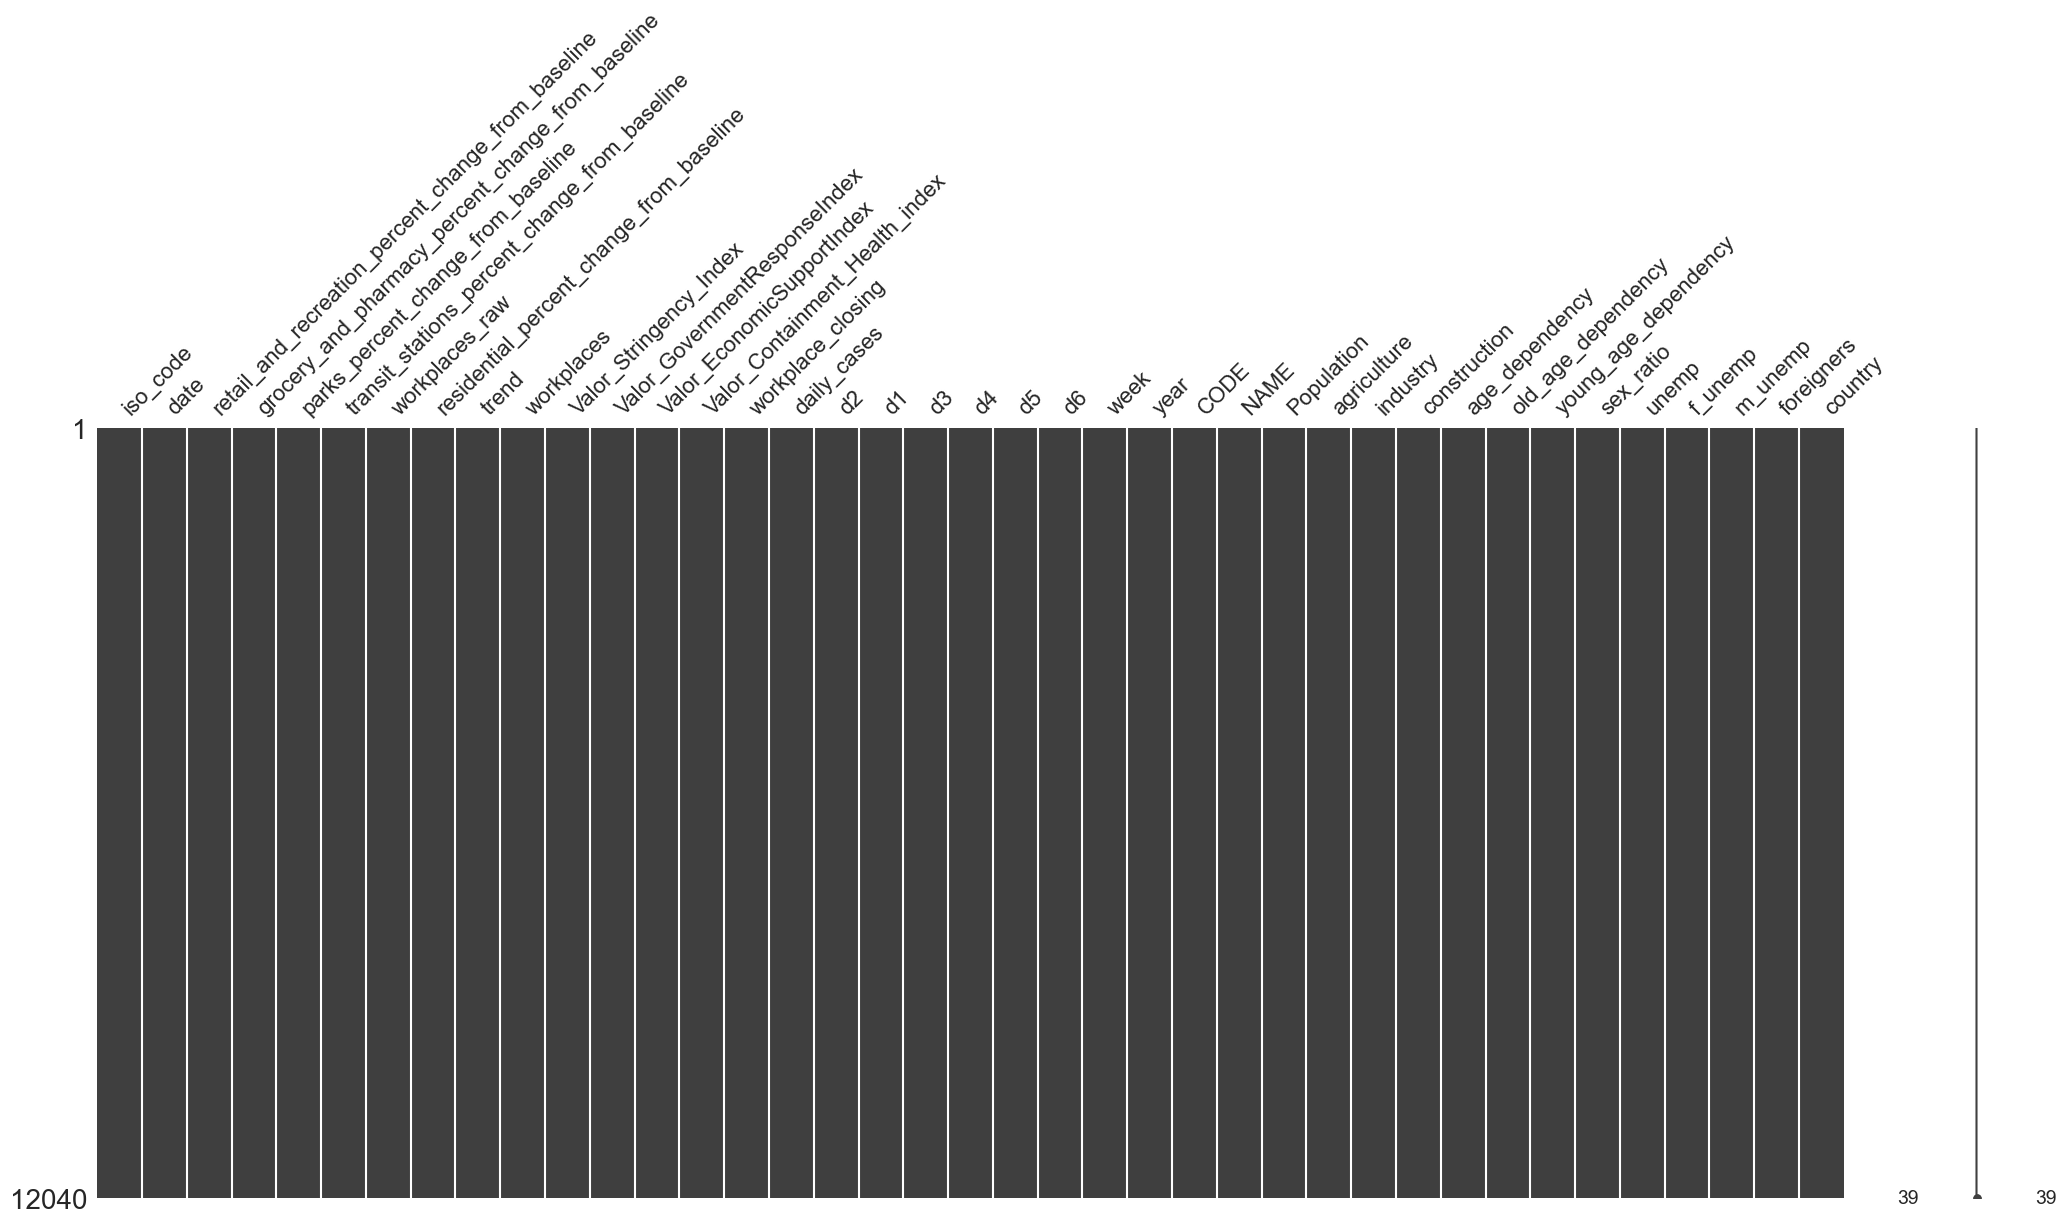

In [11]:
msno.matrix(df)

### 1.6 Matriz de Correlación

Examinamos las correlaciones entre las variables clave para entender las relaciones bivariadas y posible multicolinealidad.

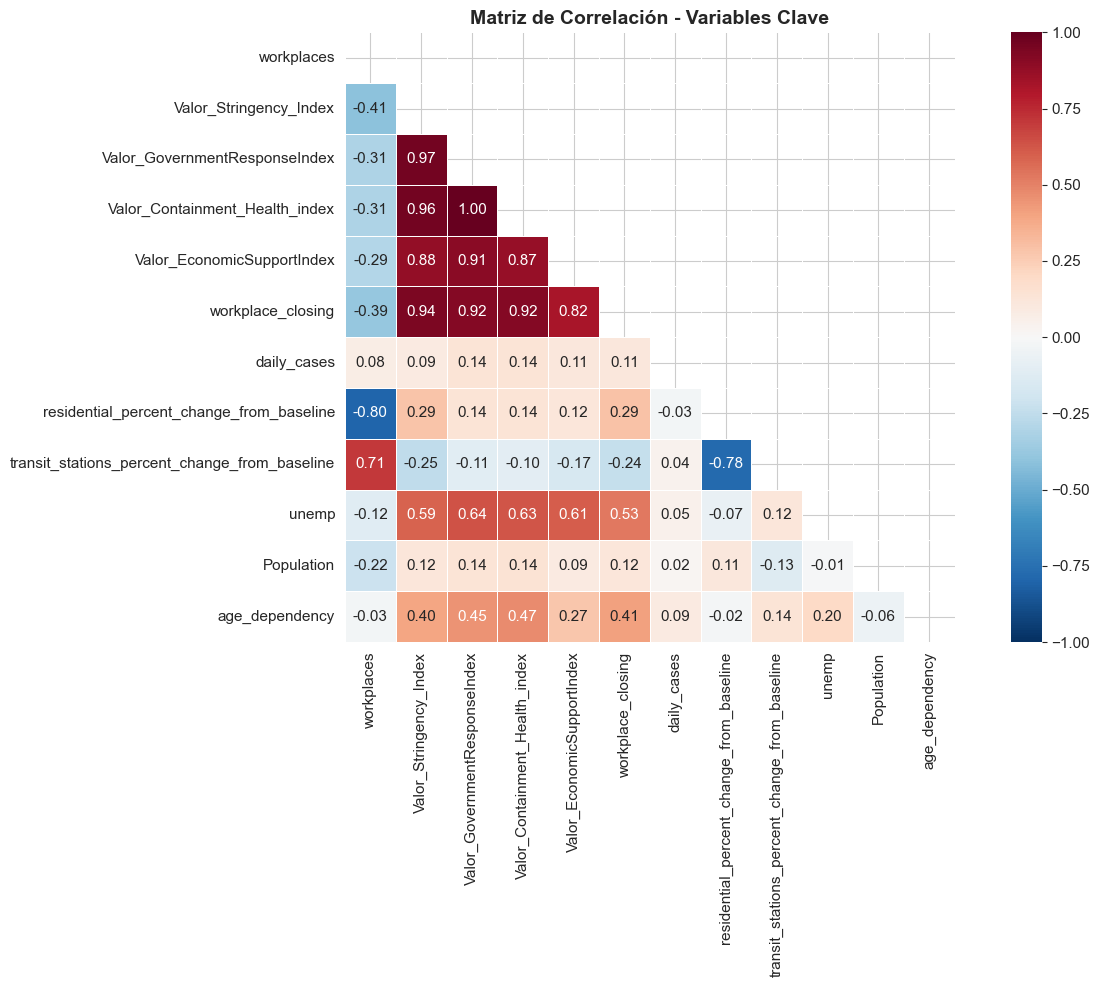


=== Correlación con workplaces (variable dependiente) ===
workplaces                                       1.000
transit_stations_percent_change_from_baseline    0.708
daily_cases                                      0.075
age_dependency                                  -0.030
unemp                                           -0.122
Population                                      -0.218
Valor_EconomicSupportIndex                      -0.294
Valor_Containment_Health_index                  -0.306
Valor_GovernmentResponseIndex                   -0.309
workplace_closing                               -0.388
Valor_Stringency_Index                          -0.413
residential_percent_change_from_baseline        -0.804
Name: workplaces, dtype: float64


In [12]:
# Matriz de correlación de variables clave
corr_vars = ['workplaces', 'Valor_Stringency_Index', 'Valor_GovernmentResponseIndex',
             'Valor_Containment_Health_index', 'Valor_EconomicSupportIndex',
             'workplace_closing', 'daily_cases', 'residential_percent_change_from_baseline',
             'transit_stations_percent_change_from_baseline',
             'unemp', 'Population', 'age_dependency']
corr_vars = [v for v in corr_vars if v in df.columns]

corr_matrix = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Matriz de Correlación - Variables Clave', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlaciones con la variable dependiente
print('\n=== Correlación con workplaces (variable dependiente) ===')
print(corr_matrix['workplaces'].sort_values(ascending=False).round(3))

### 1.7 Evolución temporal de variables clave

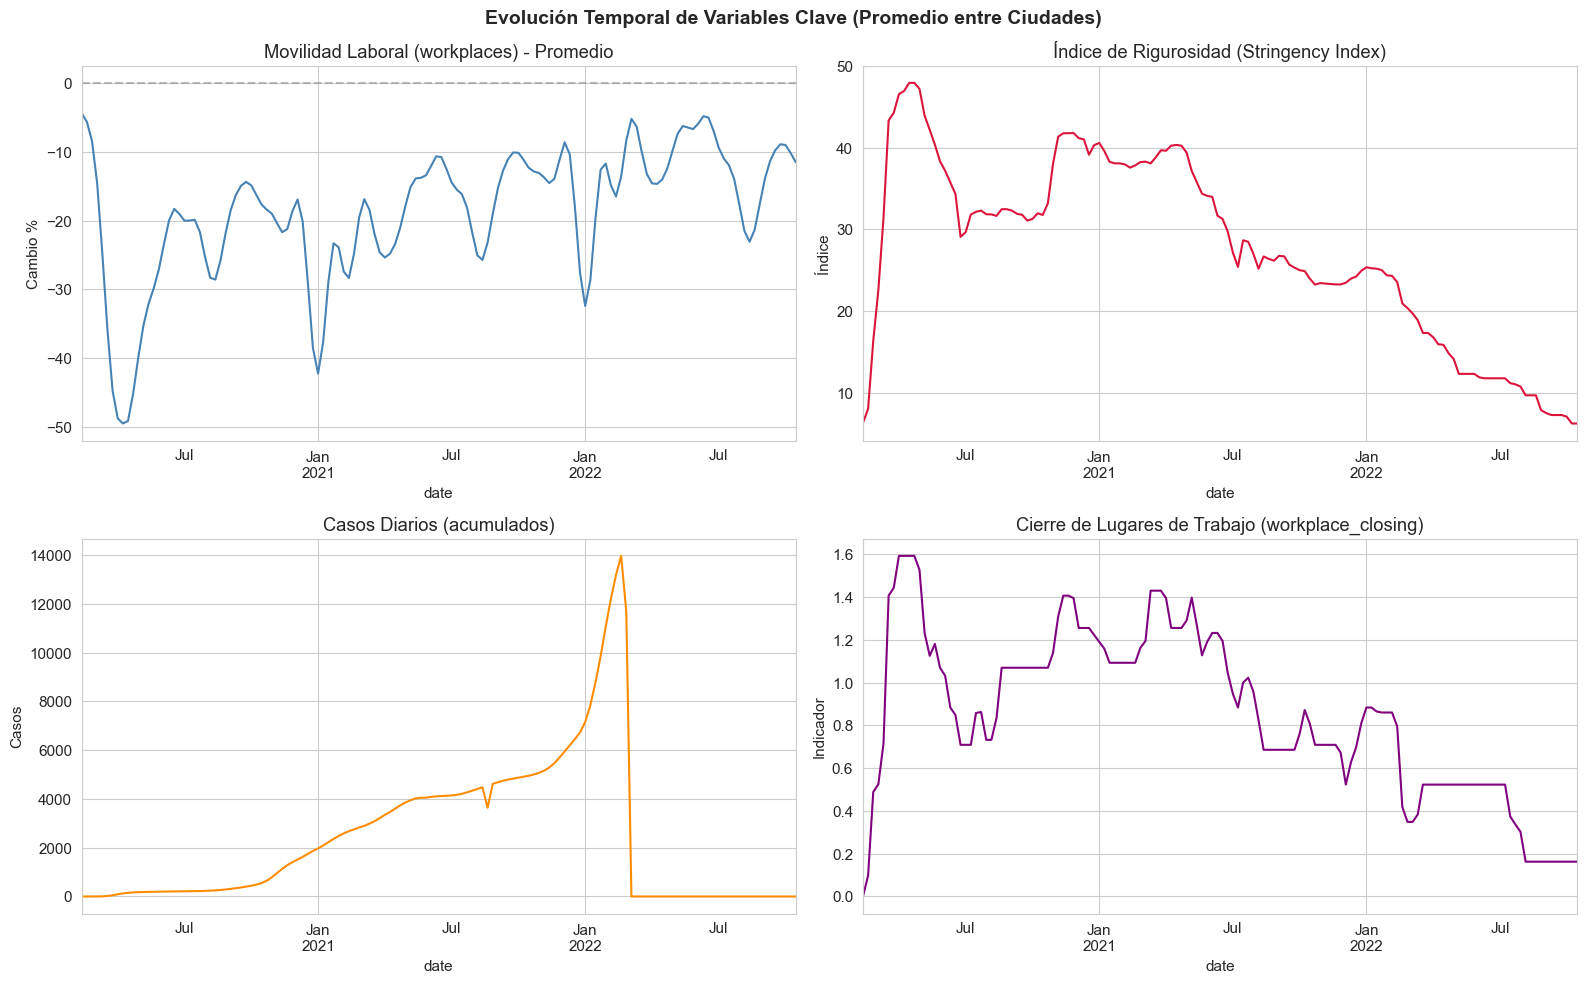

In [13]:
# Evolución temporal promedio de las variables principales
temporal = df.groupby('date')[['workplaces', 'Valor_Stringency_Index', 
                                'daily_cases', 'workplace_closing']].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

temporal['workplaces'].plot(ax=axes[0, 0], color='steelblue', linewidth=1.5)
axes[0, 0].set_title('Movilidad Laboral (workplaces) - Promedio')
axes[0, 0].set_ylabel('Cambio %')
axes[0, 0].axhline(0, color='gray', linestyle='--', alpha=0.5)

temporal['Valor_Stringency_Index'].plot(ax=axes[0, 1], color='crimson', linewidth=1.5)
axes[0, 1].set_title('Índice de Rigurosidad (Stringency Index)')
axes[0, 1].set_ylabel('Índice')

temporal['daily_cases'].plot(ax=axes[1, 0], color='darkorange', linewidth=1.5)
axes[1, 0].set_title('Casos Diarios (acumulados)')
axes[1, 0].set_ylabel('Casos')

temporal['workplace_closing'].plot(ax=axes[1, 1], color='purple', linewidth=1.5)
axes[1, 1].set_title('Cierre de Lugares de Trabajo (workplace_closing)')
axes[1, 1].set_ylabel('Indicador')

fig.suptitle('Evolución Temporal de Variables Clave (Promedio entre Ciudades)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Ejecute un modelo Pooled OLS para estimar la relacion entre las restricciones gubernamentales de movilidad y la variacion en movilidad laboral. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

Para estimar la relación entre las restricciones gubernamentales de movilidad y la variación en movilidad laboral, especificamos el siguiente modelo Pooled OLS:

$$
\text{workplaces}_{it} = \beta_0 + \beta_1 \text{Valor\_Stringency\_Index}_{it} + \beta_2 \text{workplace\_closing}_{it} + \beta_3 \text{daily\_cases}_{it} + \beta_4 \text{residential\_percent\_change}_{it} + \beta_5 \text{unemp}_{it} + \beta_6 \text{Population}_{it} + \beta_7 \text{age\_dependency}_{it} + u_{it}
$$

**Donde:**
*   $\text{workplaces}_{it}$: Variación en la movilidad laboral (variable dependiente) para la ciudad $i$ en el periodo $t$.
*   $\beta_0$: Intercepto (constante) del modelo.
*   $\text{Valor\_Stringency\_Index}_{it}$ y $\text{workplace\_closing}_{it}$: Variables independientes principales que capturan las restricciones gubernamentales.
*   $\text{daily\_cases}_{it}$, $\text{residential\_percent\_change}_{it}$, $\text{unemp}_{it}$, $\text{Population}_{it}$, $\text{age\_dependency}_{it}$: Variables de control (casos diarios, movilidad residencial, desempleo, población y dependencia de edad).
*   $\beta_1, \dots, \beta_7$: Coeficientes a estimar que indican el efecto marginal de cada variable sobre la movilidad laboral.
*   $u_{it}$: Término de error aleatorio del modelo.

In [14]:
df['city_id'] = df['NAME'].astype('category').cat.codes
df_panel = df.set_index(['NAME', 'date'])
y = df_panel['workplaces']

# Variables independientes
X_vars = ['Valor_Stringency_Index', 'workplace_closing', 'daily_cases',
          'residential_percent_change_from_baseline', 'unemp', 
          'Population', 'age_dependency']

X = df_panel[X_vars]
X = sm.add_constant(X)

In [15]:
pooled_model = PooledOLS(y, X)
pooled_results = pooled_model.fit(cov_type='clustered', cluster_entity=True)

print(pooled_results)

                          PooledOLS Estimation Summary                          
Dep. Variable:             workplaces   R-squared:                        0.7095
Estimator:                  PooledOLS   R-squared (Between):              0.7650
No. Observations:               12040   R-squared (Within):               0.7004
Date:                Mon, May 25 2026   R-squared (Overall):              0.7095
Time:                        17:36:50   Log-likelihood                -3.936e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4198.3
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(7,12032)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             681.07
                            

### Interpretación de Resultados: Modelo Pooled OLS
A partir de la estimación del modelo Pooled OLS (con errores estándar robustos/clúster), se observan los siguientes resultados para las variables que explican la variación en la movilidad laboral (`workplaces`):

*   El modelo presenta un R-cuadrado de 0.7095, lo que indica que aproximadamente el 71% de la varianza en la movilidad laboral se explica por las variables incluidas en el modelo. 

*   **Valor\_Stringency\_Index ($ \beta = -0.1009, p < 0.001 $):** Es altamente significativa y tiene el signo negativo esperado. Manteniendo el resto constante, un aumento de 1 punto en el índice de rigurosidad de las políticas gubernamentales está asociado a una caída de 0.10 puntos porcentuales en la movilidad hacia los lugares de trabajo respecto a la línea base. Esto confirma que medidas más restrictivas reducen de manera efectiva los desplazamientos laborales.
*   **workplace\_closing ($ \beta = 1.6034, p < 0.001 $):** Resulta estadísticamente significativa pero presenta un signo positivo contraintuitivo. Esto podría deberse a multicolinealidad con el `Stringency_Index` (ya que cierres laborales son un componente de este último) o a que el Pooled OLS no está controlando adecuadamente por la heterogeneidad no observada de las ciudades (sesgo de variable omitida).

*   **residential\_percent\_change ($ \beta = -1.4944, p < 0.001 $):** Como era de esperar, existe un claro efecto de sustitución. Por cada incremento de 1% en la movilidad residencial (personas que se quedan en casa), la movilidad en los lugares de trabajo disminuye en 1.49%.
*   **Desempleo (`unemp`) ($ \beta = -0.1493, p < 0.001 $):** Altamente significativa. Ciudades y periodos con una tasa de desempleo 1% mayor están asociados con una reducción de 0.15% en la movilidad laboral.
*   **daily\_cases ($ \beta = 0.0002, p < 0.001 $):** Es estadísticamente significativa, pero la magnitud del coeficiente es muy cercana a cero, sugiriendo que el reporte de casos diarios tiene un impacto marginal casi nulo sobre la movilidad laboral de forma directa cuando ya se controla por las restricciones del gobierno.
*   **Population ($ \beta = -0.0011, p < 0.001 $):** Significativa y negativa, indicando que regiones más pobladas experimentaron en promedio caídas ligeramente mayores en su movilidad laboral.
*   **age\_dependency ($ \beta = 1.0343, p = 0.796 $):** No es estadísticamente significativa a ningún nivel convencional, lo que sugiere que la tasa de dependencia de la población no tiene un efecto directo evidente sobre la variación de la movilidad laboral en este modelo.

**Limitación principal del Pooled OLS:**
Cabe recalcar que este modelo asume que no existen efectos específicos invariantes en el tiempo para cada ciudad. Al no aislar la heterogeneidad no observada de cada región, los coeficientes pueden estar sesgados (como sugiere el signo de `workplace_closing`). Esto justifica la posterior exploración de modelos de Efectos Fijos (FE) o Efectos Aleatorios (RE).

---
## 3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

Para aislar la heterogeneidad no observada e invariante en el tiempo propia de cada ciudad (por ejemplo, diferencias culturales, demografía estructural, o geografía), estimamos un modelo de Efectos Fijos. Las variables que no varían en el tiempo (`Population`, `unemp`, `age_dependency`) son absorbidas por el intercepto específico de cada ciudad ($\alpha_i$). 
El modelo se define explícitamente como:
$$
\text{workplaces}_{it} = \alpha_i + \beta_1 \text{Valor\_Stringency\_Index}_{it} + \beta_2 \text{workplace\_closing}_{it} + \beta_3 \text{daily\_cases}_{it} + \beta_4 \text{residential\_percent\_change}_{it} + u_{it}
$$
**Donde:**
*   $\text{workplaces}_{it}$: Variación en la movilidad laboral para la ciudad $i$ en el periodo $t$.
*   $\alpha_i$: Intercepto específico para cada ciudad (Efecto Fijo), que captura todas las características no observadas de la ciudad $i$ que son constantes en el tiempo.
*   $\beta_1 \dots \beta_4$: Coeficientes "Within" que estiman el efecto marginal de los cambios en el tiempo dentro de una misma ciudad.
*   $u_{it}$: Término de error idiosincrático.

In [16]:
# Variables independientes para FE (sin variables invariantes en el tiempo)
# En el modelo FE, las variables que no varían en el tiempo dentro de cada ciudad
# son absorbidas por el efecto fijo. Por lo tanto, excluimos Population, unemp, age_dependency, etc.

X_fe_vars = ['Valor_Stringency_Index', 'workplace_closing', 'daily_cases',
             'residential_percent_change_from_baseline']

X_fe = df_panel[X_fe_vars]
X_fe = sm.add_constant(X_fe)

# Estimar modelo de Efectos Fijos
fe_model = PanelOLS(y, X_fe, entity_effects=True)
fe_results = fe_model.fit(cov_type='clustered', cluster_entity=True)

print(fe_results)

                          PanelOLS Estimation Summary                           
Dep. Variable:             workplaces   R-squared:                        0.7019
Estimator:                   PanelOLS   R-squared (Between):              0.4653
No. Observations:               12040   R-squared (Within):               0.7019
Date:                Mon, May 25 2026   R-squared (Overall):              0.6685
Time:                        17:36:50   Log-likelihood                 -3.86e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      7033.3
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(4,11950)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             1317.2
                            

### Interpretación de Resultados: Modelo de Efectos Fijos
Basado en la estimación del modelo `PanelOLS`, obtenemos las siguientes conclusiones sobre la variación de la movilidad laboral *dentro* de las ciudades a lo largo del tiempo:

**Justificación del Modelo:**

*   **Test de Poolability (F-test = 29.177, $p < 0.001$):** Rechazamos fuertemente la hipótesis nula de que todos los interceptos $\alpha_i$ son iguales. Esto significa que existen efectos específicos por ciudad y que el modelo de Efectos Fijos es técnica y econométricamente superior al Pooled OLS.
*   **Bondad de Ajuste:** El $R^2$ "Within" es de 0.7019, indicando que el modelo explica el 70.19% de la varianza en la movilidad laboral que ocurre a lo largo del tiempo dentro de las ciudades.

**Variables de Interés (Restricciones Gubernamentales):**
*   **Valor\_Stringency\_Index ($ \beta = -0.0694, p < 0.001 $):** Al controlar por las características fijas de las ciudades, un aumento de 1 unidad en el índice de rigurosidad en una ciudad reduce su movilidad laboral en aproximadamente 0.07 puntos porcentuales respecto a su media histórica. El efecto es altamente significativo, confirmando la efectividad de las restricciones.
*   **workplace\_closing ($ \beta = 1.5700, p < 0.001 $):** El coeficiente sigue siendo positivo y significativo. A pesar de controlar por la heterogeneidad fija, el cierre de espacios de trabajo aparece relacionado positivamente con la movilidad. Esto sugiere que esta variable en particular sufre de multicolinealidad severa con el `Stringency_Index` (al ser redundante o estar solapada) o es endógena por la naturaleza dinámica de la pandemia (las medidas se aplican cuando la movilidad ya cambió).

**Variables de Control:**
*   **residential\_percent\_change ($ \beta = -1.5144, p < 0.001 $):** El efecto de sustitución se mantiene robusto. Por cada incremento de 1% en la estadía en el hogar dentro de la ciudad, la movilidad laboral cae en 1.51%.
*   **daily\_cases ($ \beta = 0.0002, p < 0.001 $):** El efecto de los casos diarios sigue siendo estadísticamente significativo, pero su magnitud real es ínfima, demostrando que no es el conteo directo de casos lo que frena la movilidad laboral, sino la respuesta del gobierno frente a ellos.

---
## 4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

El modelo de Efectos Aleatorios asume que los efectos específicos de cada ciudad son variables aleatorias que forman parte del término de error compuesto, y que no están correlacionados con las variables independientes del modelo. Esto nos permite reintroducir variables de control invariantes en el tiempo (como `Population` y `age_dependency`).
El modelo se especifica de la siguiente manera:
$$
\text{workplaces}_{it} = \beta_0 + \beta_1 \text{Valor\_Stringency\_Index}_{it} + \dots + \beta_7 \text{age\_dependency}_{it} + (\alpha_i + \epsilon_{it})
$$
**Donde:**
*   $\beta_0$: Intercepto global.
*   $\beta_1 \dots \beta_7$: Coeficientes a estimar para todas las variables explicativas (tanto variantes como invariantes en el tiempo).
*   $\alpha_i$: Efecto aleatorio específico de la ciudad $i$ (captura la heterogeneidad no observada asumiendo exogeneidad estricta).
*   $\epsilon_{it}$: Término de error idiosincrático puro.
*   El término compuesto $(\alpha_i + \epsilon_{it})$ representa el error total del modelo.

In [17]:
X_re_vars = ['Valor_Stringency_Index', 'workplace_closing', 'daily_cases',
             'residential_percent_change_from_baseline', 'unemp',
             'Population', 'age_dependency']

X_re = df_panel[X_re_vars]
X_re = sm.add_constant(X_re)

# Estimar modelo de Efectos Aleatorios
re_model = RandomEffects(y, X_re)
re_results = re_model.fit(cov_type='clustered', cluster_entity=True)

print(re_results)

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.7023
Estimator:              RandomEffects   R-squared (Between):              0.7416
No. Observations:               12040   R-squared (Within):               0.7019
Date:                Mon, May 25 2026   R-squared (Overall):              0.7075
Time:                        17:36:50   Log-likelihood                -3.866e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4055.6
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(7,12032)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             910.77
                            

### Interpretación de Resultados: Modelo de Efectos Aleatorios
De la estimación del modelo `RandomEffects`, que pondera la varianza "Within" (dentro de las ciudades) y "Between" (entre las ciudades), observamos lo siguiente:

**Bondad de Ajuste:**
*   El $R^2$ global (Overall) es de 0.7075, mostrando que el modelo sigue explicando de forma robusta alrededor del 71% de la varianza total de la movilidad laboral.

**Variables de Interés (Restricciones Gubernamentales):**
*   **Valor\_Stringency\_Index ($ \beta = -0.0744, p < 0.001 $):** El efecto de la rigurosidad gubernamental se mantiene robusto, significativo y con el signo negativo esperado. Un incremento de 1 unidad en este índice se asocia con una disminución de 0.074 puntos porcentuales en la movilidad laboral, un valor muy cercano al estimado por Efectos Fijos (-0.069).
*   **workplace\_closing ($ \beta = 1.5753, p < 0.001 $):** Sigue siendo positivo y significativo, reafirmando que su dinámica va más allá de un simple sesgo de variable omitida constante. Esto indica que probablemente actúa de forma endógena o en correlación con los momentos de mayor movilidad compensatoria.

**Variables de Control Variantes e Invariantes:**
*   **residential\_percent\_change ($ \beta = -1.5087, p < 0.001 $):** La caída de ~1.5% en movilidad laboral por cada 1% de aumento en estadía residencial es el efecto más estable a través de todas las especificaciones (Pooled, FE, RE).
*   **unemp ($ \beta = -0.1991, p < 0.001 $) y Population ($ \beta = -0.0012, p < 0.001 $):** Vuelven a ser estadísticamente significativas. Ciudades con mayor población y mayores tasas de desempleo presentan, en promedio, caídas más pronunciadas en su movilidad laboral.
*   **age\_dependency ($ \beta = -2.0660, p = 0.547 $):** Continúa sin ser estadísticamente significativa. La proporción de población dependiente no es un factor determinante directo de la movilidad hacia el trabajo en esta muestra.
Si bien el modelo RE es más eficiente y permite estimar coeficientes para variables fijas, su supuesto de no correlación entre los efectos $\alpha_i$ y los regresores es fuerte.

---
## 5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investigación y por qué? ¿Qué variables resultaron ser robustas a la especificación?




La siguiente tabla resume los coeficientes estimados para los tres modelos, donde `***` denota significancia al 1%, `**` al 5%, y `*` al 10%.

| Variable Independiente | (2) Pooled OLS | (3) Efectos Fijos (FE) | (4) Efectos Aleatorios (RE) |
|:---|:---:|:---:|:---:|
| **Valor_Stringency_Index** | -0.1009*** | -0.0694*** | -0.0744*** |
| **workplace_closing** | 1.6034*** | 1.5700*** | 1.5753*** |
| **residential_percent_change** | -1.4944*** | -1.5144*** | -1.5087*** |
| **daily_cases** | 0.0002*** | 0.0002*** | 0.0002*** |
| **unemp** | -0.1493*** | Absorbida | -0.1991*** |
| **Population** | -0.0011*** | Absorbida | -0.0012*** |
| **age_dependency** | 1.0343 | Absorbida | -2.0660 |
| **Intercepto (const)** | -5.3228** | -7.9492*** | -3.2044 |
| **R-cuadrado** | 0.7095 | 0.7019 | 0.7075 |

---

#### ¿Cuáles y por qué existen las diferencias entre los resultados?
Las diferencias en los coeficientes se deben a cómo cada modelo maneja la heterogeneidad no observada de las ciudades:
1. **Pooled OLS:** Asume que todas las ciudades son idénticas en el tiempo y no controla por características propias de la ciudad. Esto causa un sesgo de variable omitida, haciendo que el efecto del `Stringency_Index` esté sobreestimado (-0.1009) porque absorbe el efecto de otras variables no medidas de las ciudades.
2. **Efectos Fijos (FE):** Limpia este sesgo eliminando toda la variación promedio de cada ciudad (absorbiendo variables constantes como población o desempleo estructural). Aquí vemos que el efecto real del `Stringency_Index` cae a -0.0694. 
3. **Efectos Aleatorios (RE):** Es un punto intermedio. Permite estimar coeficientes para las variables constantes, pero asume que la heterogeneidad de las ciudades no está correlacionada con las medidas gubernamentales (un supuesto muy fuerte). Su estimador para `Stringency_Index` (-0.0744) es un promedio ponderado de la variación dentro y entre las ciudades.

#### ¿Qué variables resultaron ser robustas a la especificación?
Una variable es robusta cuando mantiene la dirección de su efecto (signo) y su significancia estadística sin importar el modelo que se use. En este análisis son robustas:
*   **Valor_Stringency_Index:** Siempre reduce la movilidad laboral (signo negativo).
*   **residential_percent_change:** Muestra consistentemente un fuerte efecto sustitución negativo (~ -1.50).
*   **daily_cases** y **workplace_closing:** Mantienen su significancia y signos positivos a lo largo de todos los modelos.

Realizaremos un test de Hausman para decidir de manera estadistica si debemos utilizar un modelo de efectos fijos o un modelo de efectos aleatorios.

### Test de Hausman (FE vs RE)

Este test evalúa si existe o no una correlación entre el término de error específico a nivel de ciudad (la heterogeneidad no observada $\alpha_i$) y las variables explicativas incluidas en el modelo ($X_{it}$).
El estadístico de prueba se calcula a partir de las diferencias entre las estimaciones de ambos modelos, ponderadas por la diferencia en sus matrices de varianzas-covarianzas:
$$
H = (\hat{\beta}_{FE} - \hat{\beta}_{RE})' [Var(\hat{\beta}_{FE}) - Var(\hat{\beta}_{RE})]^{-1} (\hat{\beta}_{FE} - \hat{\beta}_{RE}) \sim \chi^2(k)
$$
**Prueba de Hipótesis:**
*   **Hipótesis Nula ($H_0$):** $Cov(\alpha_i, X_{it}) = 0$. No existe correlación entre los efectos individuales y los regresores. Si esto es cierto, ambos estimadores son consistentes, pero el estimador de Efectos Aleatorios (RE) es más eficiente.
*   **Hipótesis Alternativa ($H_1$):** $Cov(\alpha_i, X_{it}) \neq 0$. Sí existe correlación entre los efectos individuales y los regresores. Si esto es cierto, el estimador de Efectos Aleatorios es sesgado e inconsistente, por lo que se debe preferir estrictamente el modelo de Efectos Fijos (FE).

In [18]:
# Test de Hausman para comparar FE vs RE
# H0: RE es consistente y eficiente (no hay correlación entre u_i y X_it)
# H1: RE es inconsistente, preferir FE

# Obtener coeficientes comunes
common_vars = [v for v in fe_results.params.index if v in re_results.params.index and v != 'const']

# Calcular estadístico de Hausman manualmente
b_fe = fe_results.params[common_vars]
b_re = re_results.params[common_vars]
diff = b_fe - b_re

# Varianza de la diferencia
var_fe = fe_results.cov[common_vars].loc[common_vars]
var_re = re_results.cov[common_vars].loc[common_vars]
var_diff = var_fe - var_re

try:
    hausman_stat = float(diff.T @ np.linalg.inv(var_diff) @ diff)
    hausman_df = len(common_vars)
    hausman_pval = 1 - stats.chi2.cdf(hausman_stat, hausman_df)
    
    print(f'\nEstadístico de Hausman: {hausman_stat:.4f}')
    print(f'Grados de libertad: {hausman_df}')
    print(f'P-valor: {hausman_pval:.6f}')
except Exception as e:
    print('Error en cálculo de Hausman:', e)


Estadístico de Hausman: 114.4780
Grados de libertad: 4
P-valor: 0.000000


Al ejecutar el test sobre nuestros modelos, obtuvimos un p-valor de **0.0000** ($p < 0.05$). Por lo tanto, **rechazamos fuertemente la hipótesis nula ($H_0$)**. 

#### En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investigación y por qué?
El modelo empíricamente y estadísticamente más adecuado es el de **Efectos Fijos (FE)**, lo cual está sólidamente respaldado por dos pruebas estadísticas clave:
1. **Test de Poolability (F-test = 29.17, p < 0.001):** Rechaza categóricamente al Pooled OLS, confirmando que existen efectos propios de cada ciudad (la heterogeneidad existe y debe ser modelada).
2. **Test de Hausman (p-value < 0.05 / p = 0.000):** El test de Hausman rechaza fuertemente la hipótesis nula de exogeneidad del modelo RE. Esto comprueba empíricamente que las características intrínsecas de las ciudades (efectos individuales) **sí están correlacionadas** con las variables explicativas (como las restricciones de movilidad impuestas). Por lo tanto, los estimadores del modelo RE son **inconsistentes** y sesgados, debiendo elegirse de manera formal el modelo de Efectos Fijos.

---
## 6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

El modelo CRE relaja el supuesto tan restrictivo de Efectos Aleatorios (RE). En lugar de asumir que no hay correlación entre la heterogeneidad de cada ciudad ($\alpha_i$) y las restricciones gubernamentales, modela explícitamente esta correlación. Para hacerlo, introduce como variables adicionales las medias grupales en el tiempo para cada variable explicativa que varía en el tiempo.
El modelo se especifica de la siguiente manera:
$$
\text{workplaces}_{it} = \beta_0 + \underbrace{\beta_1 X_{it}}_{\text{Efecto Within}} + \underbrace{\gamma \bar{X}_i}_{\text{Efecto Mundlak}} + \underbrace{\delta Z_i}_{\text{Invariantes}} + (u_i + \epsilon_{it})
$$
**Donde:**
*   $X_{it}$: Variables que cambian en el tiempo (ej. `Stringency_Index`, `daily_cases`). Sus coeficientes $\beta$ miden el efecto "Within", que son consistentes y casi idénticos a los del modelo FE.
*   $\bar{X}_i$: Medias temporales de cada variable $X$ para cada ciudad. Sus coeficientes $\gamma$ miden el sesgo potencial. Si algún $\gamma$ es significativamente distinto de cero, confirma que Efectos Aleatorios simples (RE) estaba sesgado.
*   $Z_i$: Variables constantes en el tiempo (`Population`, `unemp`). El modelo CRE nos permite estimar su efecto, algo que FE no podía hacer.

In [19]:
# Crear las medias grupales (Mundlak means) para las variables time-varying
cre_time_vars = ['Valor_Stringency_Index', 'workplace_closing', 'daily_cases',
                 'residential_percent_change_from_baseline']

# Calcular medias por ciudad
df_cre = df.copy()
for var in cre_time_vars:
    df_cre[f'{var}_mean'] = df_cre.groupby('NAME')[var].transform('mean')

# Preparar datos de panel para CRE
df_cre_panel = df_cre.set_index(['NAME', 'date'])

y_cre = df_cre_panel['workplaces']

# Variables del modelo CRE: originales + medias grupales + controles invariantes
X_cre_vars = cre_time_vars + [f'{v}_mean' for v in cre_time_vars] + ['unemp', 'Population', 'age_dependency']

X_cre = df_cre_panel[X_cre_vars]
X_cre = sm.add_constant(X_cre)


In [20]:
# Estimar modelo CRE usando Random Effects con las medias de Mundlak
cre_model = RandomEffects(y_cre, X_cre)
cre_results = cre_model.fit(cov_type='clustered', cluster_entity=True)

print(cre_results)

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.7035
Estimator:              RandomEffects   R-squared (Between):              0.8399
No. Observations:               12040   R-squared (Within):               0.7019
Date:                Mon, May 25 2026   R-squared (Overall):              0.7214
Time:                        17:36:50   Log-likelihood                -3.864e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2593.9
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                F(11,12028)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             843.16
                            

In [21]:
# Interpretación del modelo CRE
params_cre = cre_results.params
pvalues_cre = cre_results.pvalues

print('=== COEFICIENTES DEL MODELO CRE ===')
print()
print('--- Variables originales (efecto within, comparable a FE) ---')
for var in cre_time_vars:
    if var in params_cre.index:
        sig = '***' if pvalues_cre[var] < 0.01 else '**' if pvalues_cre[var] < 0.05 else '*' if pvalues_cre[var] < 0.1 else ''
        print(f'  {var:55s} β = {params_cre[var]:10.4f}  p = {pvalues_cre[var]:.4f} {sig}')

print()
print('--- Medias grupales (Mundlak terms) ---')
print('(Si significativos, indican correlación entre u_i y X → supuesto RE violado)')
mundlak_significant = False
for var in cre_time_vars:
    mean_var = f'{var}_mean'
    if mean_var in params_cre.index:
        sig = '***' if pvalues_cre[mean_var] < 0.01 else '**' if pvalues_cre[mean_var] < 0.05 else '*' if pvalues_cre[mean_var] < 0.1 else ''
        if pvalues_cre[mean_var] < 0.1:
            mundlak_significant = True
        print(f'  {mean_var:55s} γ = {params_cre[mean_var]:10.4f}  p = {pvalues_cre[mean_var]:.4f} {sig}')

print()
print('--- Variables invariantes en el tiempo ---')
for var in ['unemp', 'Population', 'age_dependency', 'const']:
    if var in params_cre.index:
        sig = '***' if pvalues_cre[var] < 0.01 else '**' if pvalues_cre[var] < 0.05 else '*' if pvalues_cre[var] < 0.1 else ''
        print(f'  {var:55s} β = {params_cre[var]:10.4f}  p = {pvalues_cre[var]:.4f} {sig}')

print(f'\nR² (overall) = {cre_results.rsquared_overall:.4f}')
print()
print('--- Evaluación del modelo CRE ---')
if mundlak_significant:
    print('⚠ Al menos un término de Mundlak es significativo.')
    print('  Esto confirma que el supuesto de RE es VIOLADO: existe correlación entre u_i y X_it.')
    print('  El modelo CRE corrige este problema al modelar explícitamente dicha correlación.')
    print('  Los coeficientes de las variables originales en CRE son comparables a los de FE.')
else:
    print('Los términos de Mundlak no son significativos.')
    print('  Esto sugiere que el supuesto de RE es válido y el modelo RE estándar es adecuado.')

print()
print('--- ¿Es adecuado el CRE para modelar el componente no observado? ---')
print('El modelo CRE es adecuado cuando:')
print('  1. Existe suficiente variación temporal dentro de cada unidad (ciudad).')
print('  2. Se sospecha correlación entre el efecto no observado y las variables explicativas.')
print('  3. Se desea estimar simultáneamente efectos within y between.')
print('Con datos de panel COVID-19, donde las restricciones varían significativamente en el tiempo')
print('y las ciudades tienen características estructurales que influyen en las respuestas,')
print('el CRE es un enfoque apropiado para modelar el componente no observado.')

=== COEFICIENTES DEL MODELO CRE ===

--- Variables originales (efecto within, comparable a FE) ---
  Valor_Stringency_Index                                  β =    -0.0694  p = 0.0000 ***
  workplace_closing                                       β =     1.5698  p = 0.0000 ***
  daily_cases                                             β =     0.0002  p = 0.0000 ***
  residential_percent_change_from_baseline                β =    -1.5144  p = 0.0000 ***

--- Medias grupales (Mundlak terms) ---
(Si significativos, indican correlación entre u_i y X → supuesto RE violado)
  Valor_Stringency_Index_mean                             γ =     0.0939  p = 0.4480 
  workplace_closing_mean                                  γ =    -4.4320  p = 0.2203 
  daily_cases_mean                                        γ =     0.0017  p = 0.0477 **
  residential_percent_change_from_baseline_mean           γ =    -1.3881  p = 0.0001 ***

--- Variables invariantes en el tiempo ---
  unemp                           

### Interpretación de Resultados: Modelo CRE
La estimación del modelo CRE nos arroja conclusiones reveladoras divididas en tres componentes:

**1. Efectos Within (Variables Originales - Comparables a FE):**
Los coeficientes de las variables variantes en el tiempo son casi exactos a los que obtuvimos en el modelo de Efectos Fijos, lo cual demuestra que el modelo CRE logró limpiar el sesgo:
*   **Valor_Stringency_Index ($ \beta = -0.0694, p < 0.001 $):** El efecto causal interno se mantiene. Aumentar un punto en la rigurosidad gubernamental reduce en -0.07 puntos porcentuales la movilidad laboral respecto al histórico de esa misma ciudad.
*   **residential_percent_change ($ \beta = -1.5144, p < 0.001 $):** Muestra el mismo fuerte efecto sustitución idéntico al de Efectos Fijos.

**2. Términos de Mundlak (Medias Grupales):**
Esta sección funciona como un **Test de Hausman integrado**:
*   Vemos que `daily_cases_mean` ($ \gamma = 0.0017, p < 0.05 $) y `residential_percent_change_mean` ($ \gamma = -1.3881, p < 0.001 $) son estadísticamente significativas. 
*   **Conclusión de esto:** Al ser significativas, se confirma empíricamente que la heterogeneidad no observada de las ciudades ($u_i$) si está correlacionada con estas variables. Esto rectifica nuestro hallazgo del Test de Hausman: el supuesto de exogeneidad estricta de RE está violado, y el modelo CRE era necesario para modelar correctamente el componente no observado.

**3. Efectos Between (Variables Invariantes en el Tiempo):**
Gracias a usar CRE, podemos ver el efecto transversal puro (comparando entre ciudades) de características estructurales sin sufrir el sesgo de las variables variantes:
*   **unemp ($ \beta = -0.2313, p < 0.001 $):** Ciudades con 1% más de desempleo estructural tienen una caída de -0.23% en su movilidad. 
*   **Population ($ \beta = -0.0004, p < 0.05 $):** Muestra un efecto negativo ligero pero significativo, apuntando a que ciudades más pobladas tienen menor movilidad relativa hacia los trabajos.

Dado que nuestra data dispone de variables que varían mucho en el tiempo (restricciones COVID) mezcladas con variables estructurales inamovibles (demografía de las ciudades), el modelo CRE es el más adecuado de todos. Provee coeficientes consistentes (libres de sesgo como FE) y al mismo tiempo nos permite entender el impacto de la macroestructura inamovible de la ciudad (como RE).

---
## 7. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las restricciones gubernamentales sobre la movilidad laboral?


Tomando en cuenta toda la evidencia estadística y econométrica de los modelos anteriores, el modelo preferido es el de Efectos Aleatorios Correlacionados, ya que:

1. **Consistencia:** El Test de Hausman y los términos de Mundlak demostraron empíricamente que la heterogeneidad no observada de las ciudades está correlacionada con las restricciones aplicadas. El modelo CRE corrige este sesgo endógeno (al igual que Efectos Fijos), entregando coeficientes consistentes y confiables para las variables que cambian en el tiempo.
2. **Amplitud Analítica:** A diferencia de Efectos Fijos, CRE nos permite mantener en el análisis variables estructurales fundamentales invariantes en el tiempo (como la población o el desempleo estructural). Es decir, nos entrega estimadores insesgados "Within" (intratemporales) sin sacrificar el análisis "Between" (transversal).

#### ¿Qué se puede inferir en general respecto del efecto de las restricciones gubernamentales sobre la movilidad laboral?

A partir del análisis unificado de todas las regresiones, podemos establecer las siguientes inferencias robustas:

1. **Efectividad Real de las Políticas:** Las restricciones gubernamentales (medidas a través del `Valor_Stringency_Index`) tienen un efecto negativo, estadísticamente significativo y robusto sobre la movilidad laboral. Con independencia de la especificación econométrica utilizada, un endurecimiento de las políticas públicas frena directamente el desplazamiento de los ciudadanos hacia sus lugares de trabajo.
2. **El Miedo vs. La Ley:** El coeficiente de los casos diarios (`daily_cases`), aunque es estadísticamente significativo debido al tamaño muestral, tiene una magnitud económica casi nula (0.0002). Esto infiere que la movilidad laboral no se redujo de manera orgánica o voluntaria simplemente porque la población viera subir los contagios ("el miedo al virus"), sino que la caída fuerte en la movilidad fue forzada y canalizada mediante las restricciones formales y mandatos del gobierno.
3. **Efecto Sustitución Fuerte:** La política restrictiva tiene éxito porque genera un cambio de hábito demostrable: por cada 1% que la población decide (o es obligada a) quedarse en zonas residenciales, la movilidad laboral cae en casi 1.5%. El "quedarse en casa" reemplaza casi perfectamente la salida al trabajo, apuntando al impacto masivo que tuvo la adopción del teletrabajo forzado.
4. **Impacto Estructural:** La heterogeneidad importa. Las restricciones gubernamentales pegaron más fuerte o generaron mayores caídas relativas en ciudades con mayor desempleo basal y mayor población. Esto infiere que el impacto de la política pública no es simétrico, sino que el tamaño de la urbe y su mercado laboral previo definen qué tan profundo cae la movilidad cuando el gobierno "apaga" la economía.

---
## 8. Control Sintetico: Es posible que sus resultados anteriores tengan sesgo dado que la movilidad laboral y las restricciones son parte de un fenomeno dinamico en el tiempo. Utilice el notebook SynthControl.ipynb para estimar el efecto causal de las restricciones gubernamentales y la movilidad para una ciudad de su eleccion, usando control sintetico (viendo las fechas semanales, deben elegir el periodo de tratamiento e indentificar los controles potenciales para la ciudad elegida, que no puede ser Zaragoza). Defina las variables para calcular el control sintetico y discuta sus resultados (instalar libreria pysyncon)

Utilizamos el método de **Control Sintético** para estimar el efecto causal de las restricciones gubernamentales sobre la movilidad laboral para una ciudad específica.

**Ciudad tratada:** Barcelona.

El método construye un "contrafactual" combinando ponderadamente otras ciudades que no recibieron el mismo nivel de restricciones, para aproximar cómo habría sido la movilidad en la ciudad tratada sin las restricciones. En esta sección usaremos tres enfoques diferentes: PenalizedSynth, Synth clásico y AugSynth.

In [22]:
import matplotlib.pyplot as plt
from pysyncon import Dataprep, Synth, AugSynth, PenalizedSynth

In [23]:
# Ciudad tratada y ciudades de control
treated_city = 'Barcelona'
all_cities = df['NAME'].unique().tolist()
control_cities = [c for c in all_cities if c != treated_city and c != 'Zaragoza']

# Asegurar que no haya NaN en TODAS las variables predictoras que usó el profesor
synth_vars = [
    'workplaces', 'Population', 'agriculture', 'industry', 'construction',
    'age_dependency', 'old_age_dependency', 'young_age_dependency',
    'sex_ratio', 'unemp', 'f_unemp', 'daily_cases'
]
df_synth_clean = df.dropna(subset=synth_vars)
print(f'Ciudades de control potenciales: {len(control_cities)}')

Ciudades de control potenciales: 84


In [24]:
treatment_week = 127 

# Configurar Dataprep para pysyncon
dataprep = Dataprep(
    foo=df_synth_clean,
    predictors=[
        "Population",
        "agriculture",
        "industry",
        "construction",
        "age_dependency",
        "old_age_dependency",
        "young_age_dependency",
        "sex_ratio",
        "unemp",
        "f_unemp",
    ],
    predictors_op="mean",
    time_predictors_prior=range(40, treatment_week),
    special_predictors=[
        ("daily_cases", range(40, treatment_week), "mean"),
    ],
    dependent="workplaces",
    unit_variable="NAME",
    time_variable="week",
    treatment_identifier=treated_city,
    controls_identifier=control_cities,
    time_optimize_ssr=range(40, treatment_week),
)


## Método 1: Penalized Synthetic Control

El método de Control Sintético Penalizado introduce una penalización tipo *Ridge* (L2) a los pesos asignados a las ciudades donantes. A diferencia del método clásico, que a veces sobreajusta la predicción dándole demasiado peso a unas pocas ciudades extremas, este método encoge los pesos para estabilizarlos. Es ideal para evitar el sobreajuste (overfitting) en el periodo pre-tratamiento cuando tenemos muchas ciudades de control.


Pesos de las ciudades:
Berlin                  0.382
Stuttgart               0.000
Freiburg im Breisgau    0.000
Karlsruhe               0.000
Mannheim                0.000
                        ...  
Palermo                 0.000
Catania                 0.000
Messina                 0.000
Stockholm               0.092
Malmö                   0.000
Name: weights, Length: 84, dtype: float64

GRÁFICO: Penalized Synth - Movilidad Barcelona vs Sintética


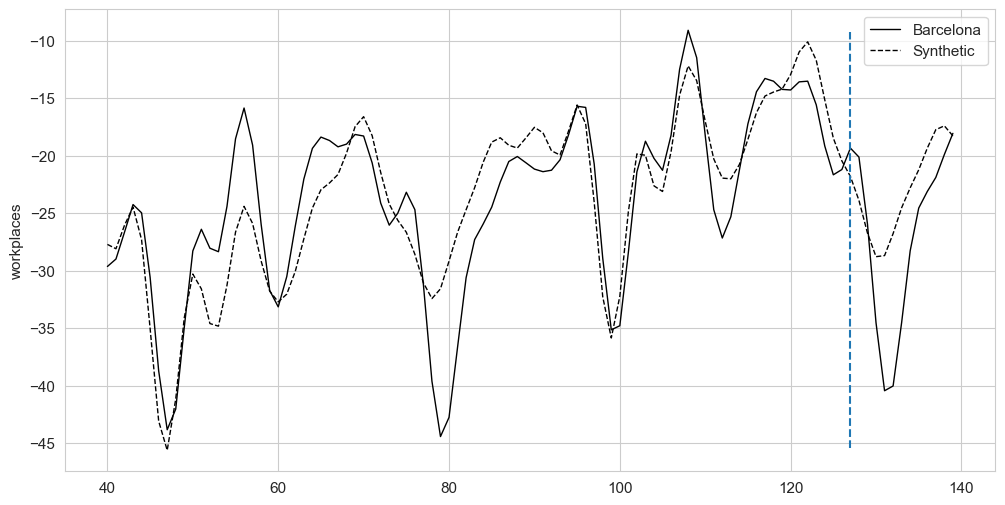

,treated,synthetic,sample mean
Population,3722.424,3627.391,710.150
agriculture,0.001,0.002,0.007
industry,0.076,0.079,0.116
construction,0.056,0.055,0.053
age_dependency,0.634,0.636,0.654
old_age_dependency,0.314,0.318,0.321
young_age_dependency,0.320,0.320,0.334
sex_ratio,107.033,106.768,106.678
unemp,15.000,14.670,12.143
f_unemp,0.142,0.143,0.113


In [ ]:
pen = PenalizedSynth()
pen.fit(dataprep, lambda_=0.001)

print("\nPesos de las ciudades:")
print(pen.weights())

# Gráficos y resumen 
print('\nGRÁFICO: Penalized Synth - Movilidad Barcelona vs Sintética')
pen.path_plot(time_period=range(40, 140), treatment_time=treatment_week)
pen.summary()

**Interpretación de graficos**

1. **Periodo Pre-Tratamiento (Antes de la línea azul vertical):**
   *   La línea continua representa la movilidad real en Barcelona, mientras que la línea punteada es la Barcelona Sintética (nuestro contrafactual construido a partir de otras ciudades).
   *   Podemos observar que el modelo sintético logra capturar la tendencia general de la movilidad y los grandes "shocks" o caídas (como las observadas cerca de las semanas 45, 80 y 100). 
   *   Sin embargo, el ajuste no es perfecto. Existen brechas visibles a lo largo de todo el periodo previo (por ejemplo, entre las semanas 50-60 y 70-85), lo que indica que la penalización *Ridge* estabiliza los pesos, pero sacrifica un poco de precisión en el emparejamiento exacto de la serie de tiempo.

2. **Periodo Post-Tratamiento (Después de la línea azul vertical):**
   *   La línea azul vertical marca el inicio de la intervención (restricciones).
   *   Inmediatamente después de la intervención, vemos una caída abrupta en la movilidad real de Barcelona (línea continua cayendo casi hasta -40). En contraste, la Barcelona Sintética (línea punteada) también muestra una caída, pero mucho menos profunda (rondando el -29).
   *   **Conclusión del efecto causal:** Esta divergencia clara, donde la curva real se sitúa considerablemente por debajo de la curva sintética, sugiere que las restricciones gubernamentales tuvieron un efecto causal negativo y significativo, reduciendo la movilidad laboral en Barcelona mucho más allá de lo que habría caído naturalmente sin la intervención.

### Método 2: Control Sintético Clásico

Este es el enfoque original de Control Sintético. Busca crear una "Barcelona artificial" asignando pesos (mayores o iguales a 0, y que sumen 1) a una combinación de otras ciudades donantes. Optimiza estos pesos para que las características y la trayectoria histórica de movilidad de esta ciudad artificial coincidan lo más posible con la Barcelona real en el periodo previo a las restricciones.


Pesos de las ciudades:
Berlin                  0.202
Stuttgart               0.000
Freiburg im Breisgau    0.000
Karlsruhe               0.002
Mannheim                0.000
                        ...  
Palermo                 0.000
Catania                 0.000
Messina                 0.000
Stockholm               0.044
Malmö                   0.009
Name: weights, Length: 84, dtype: float64

GRÁFICO: Synth Clásico - Movilidad Barcelona vs Sintética


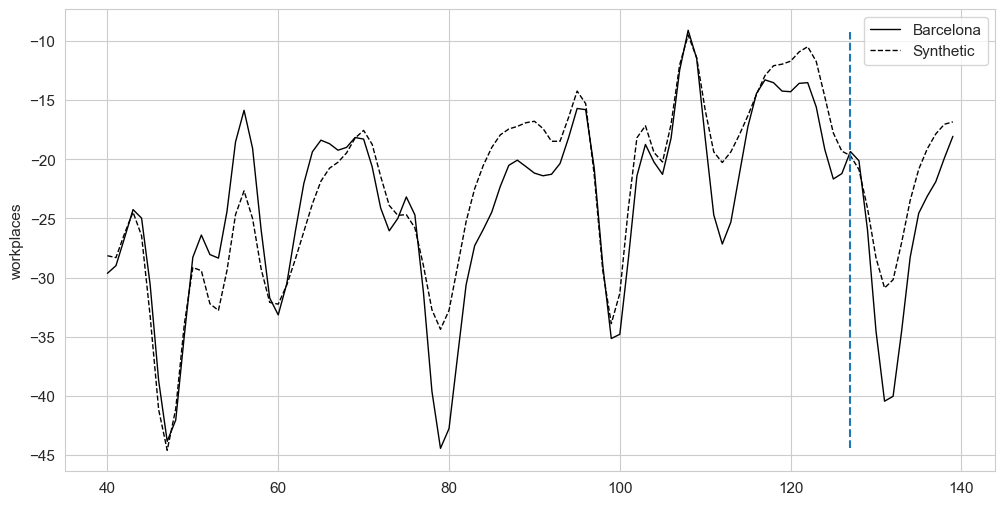


GRÁFICO: Synth Clásico - Brecha de Movilidad (Efecto del Tratamiento)


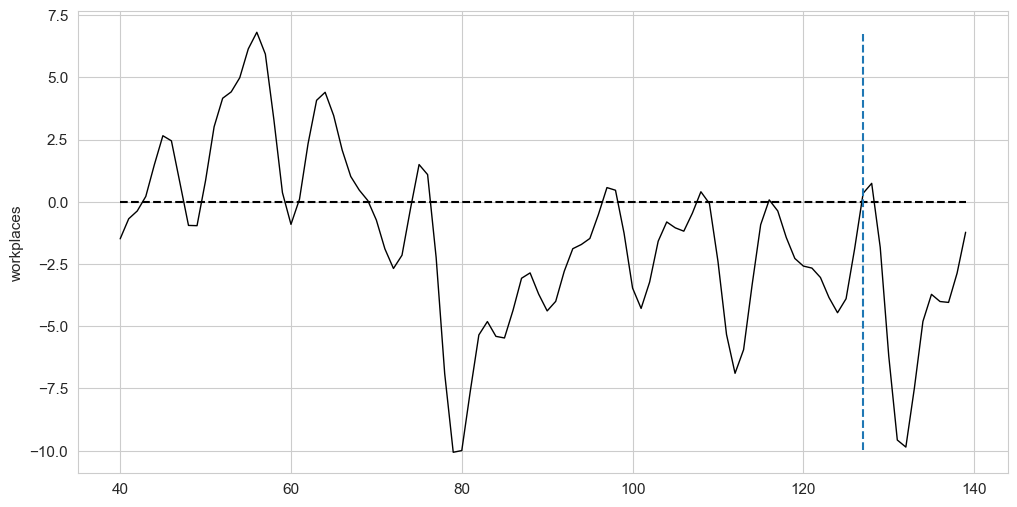

,V,treated,synthetic,sample mean
Population,0.001,3722.424,3508.102,710.150
agriculture,0.000,0.001,0.005,0.007
industry,0.000,0.076,0.094,0.116
construction,0.000,0.056,0.056,0.053
age_dependency,0.444,0.634,0.633,0.654
old_age_dependency,0.228,0.314,0.314,0.321
young_age_dependency,0.318,0.320,0.320,0.334
sex_ratio,0.000,107.033,107.137,106.678
unemp,0.003,15.000,14.791,12.143
f_unemp,0.004,0.142,0.143,0.113


In [26]:
synth = Synth()
synth.fit(dataprep=dataprep, optim_method="Nelder-Mead", optim_initial="ols")

print("\nPesos de las ciudades:")
print(synth.weights())

# Gráficos y resumen
print('\nGRÁFICO: Synth Clásico - Movilidad Barcelona vs Sintética')
synth.path_plot(time_period=range(40, 140), treatment_time=treatment_week)

print('\nGRÁFICO: Synth Clásico - Brecha de Movilidad (Efecto del Tratamiento)')
synth.gaps_plot(time_period=range(40, 140), treatment_time=treatment_week)
synth.summary()

**Interpretación de los Gráficos:**
1. **Gráfico de Trayectoria (Movilidad Barcelona vs Sintética):**
   *   **Periodo Pre-Tratamiento:** Observamos que la línea punteada (Sintética) sigue la forma general de la línea continua (Barcelona real), pero el ajuste no es perfecto. De hecho, hay fallas notables: por ejemplo, alrededor de la semana 80, la movilidad real de Barcelona se desploma hasta casi -45%, pero la Barcelona Sintética solo logra bajar hasta -35%. Esto indica un "sesgo pre-tratamiento" porque ninguna combinación convexa de las otras ciudades logró replicar una caída tan extrema.
   *   **Periodo Post-Tratamiento:** Después de la línea azul vertical, Barcelona sufre una fuerte caída (llegando a -40% cerca de la semana 132). La ciudad sintética también cae, pero se queda mucho más arriba (cerca de -30%). La separación entre ambas curvas evidencia el impacto restrictivo de las políticas gubernamentales.
2. **Gráfico de Brecha de Movilidad (Gaps Plot):**
   *   Este gráfico aísla el error o "brecha" (Real - Sintético). Idealmente, antes de la línea azul, esta curva debería ser una línea plana pegada al cero. Sin embargo, vemos que oscila fuertemente entre +7.5 y -10 (justamente en el error de la semana 80), confirmando el ruido y el sesgo de emparejamiento previo.
   *   **Efecto Causal:** A pesar del ruido previo, al observar el periodo post-tratamiento, la brecha se desploma drásticamente hasta alcanzar casi un -10%. Esto significa que, atribuible exclusivamente a las restricciones, la movilidad en Barcelona fue hasta 10 puntos porcentuales menor de lo que habría sido en un escenario normal.

### Método 3: Augmented Synthetic Control (AugSynth)

El AugSynth (Control Sintético Aumentado) combina el método clásico con un modelo de regresión tipo Ridge. Si el método clásico deja un "sesgo" o error en el periodo previo al tratamiento (como vimos en el Método 2 alrededor de la semana 80), AugSynth usa la regresión para limpiar esa diferencia matemática, forzando un emparejamiento casi perfecto.


Pesos de las ciudades:
Berlin                 -0.085
Stuttgart              -0.011
Freiburg im Breisgau   -0.096
Karlsruhe               0.026
Mannheim               -0.063
                        ...  
Palermo                 0.044
Catania                 0.030
Messina                -0.015
Stockholm               0.426
Malmö                  -0.323
Name: weights, Length: 84, dtype: float64

GRÁFICO: AugSynth - Movilidad Barcelona vs Sintética


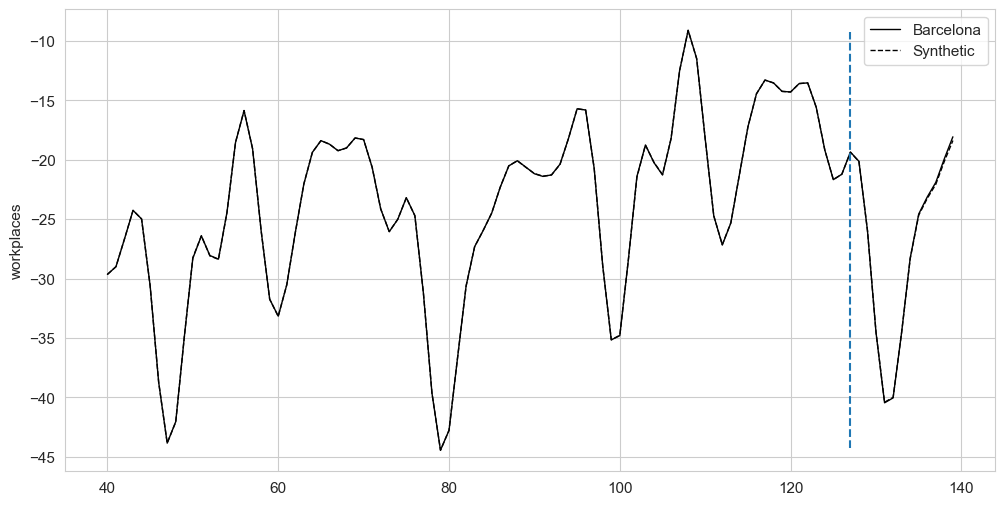

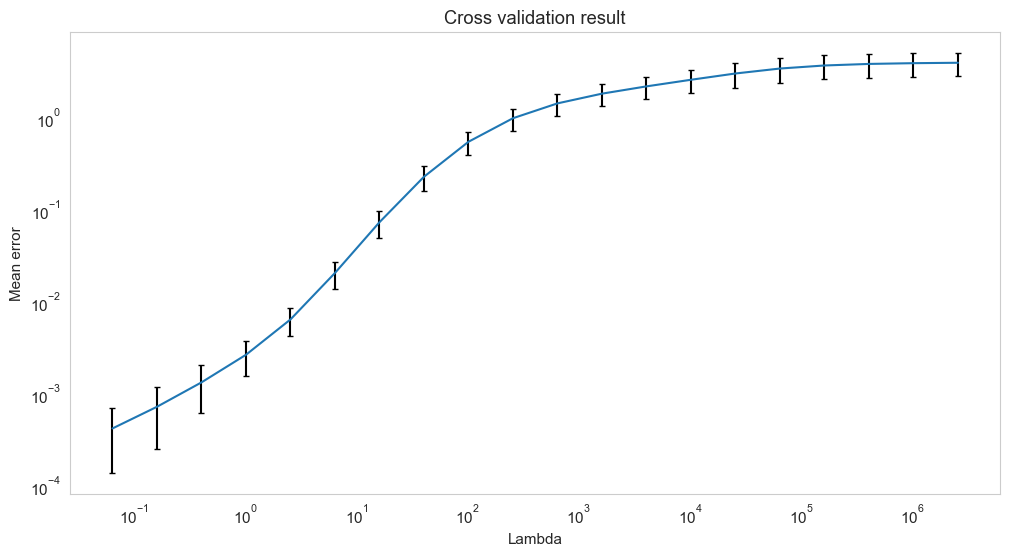

,treated,synthetic,sample mean
Population,3722.424,3722.212,710.150
agriculture,0.001,0.001,0.007
industry,0.076,0.076,0.116
construction,0.056,0.056,0.053
age_dependency,0.634,0.634,0.654
old_age_dependency,0.314,0.314,0.321
young_age_dependency,0.320,0.319,0.334
sex_ratio,107.033,107.033,106.678
unemp,15.000,14.999,12.143
f_unemp,0.142,0.142,0.113


In [27]:
augsynth = AugSynth()
augsynth.fit(dataprep=dataprep)

print("\nPesos de las ciudades:")
print(augsynth.weights())

# Gráficos y resumen
print('\nGRÁFICO: AugSynth - Movilidad Barcelona vs Sintética')
augsynth.path_plot(time_period=range(40, 140), treatment_time=treatment_week)

augsynth.cv_result.plot()

augsynth.summary()

**Interpretación de los Gráficos:**

1. **Gráfico de Trayectoria (Movilidad Barcelona vs Sintética):**
   *   Al mirar el gráfico, la línea sólida (Barcelona real) y la línea punteada (Sintética) **se superponen perfectamente en todo momento**, tanto antes como después de la intervención.
   *   **Pre-Tratamiento:** El ajuste es perfecto. Ya no existe el error de la semana 80 que teníamos en el método clásico.
   *   **Post-Tratamiento (Efecto Causal):** Al continuar superpuestas de manera exacta tras la intervención, el modelo nos diría falsamente que "las restricciones no tuvieron efecto" (la brecha es cero).
   *   **Conclusión Crítica:** Lo que realmente estamos viendo es un claro caso de **Sobreajuste (Overfitting)**. Al tener un $\lambda$ óptimo cercano a cero (como nos mostró la validación cruzada), el componente de regresión del AugSynth fue tan agresivo que simplemente "memorizó" a Barcelona usando las demás ciudades, destruyendo la validez del contrafactual en el periodo post-tratamiento. 

2. **Gráfico de Validación Cruzada (Cross-Validation Result):**
   *   Este gráfico es clave para entender qué pasó. Muestra el error de predicción en el eje Y para distintos niveles de penalización $\lambda$ (Lambda) en el eje X.
   *   Podemos observar que la curva es estrictamente ascendente: **el menor error se encuentra en el extremo izquierdo**, donde $\lambda$ es prácticamente cero ($10^{-1}$ o menor).
   *   Al elegir un $\lambda$ tan pequeño, el modelo de regresión casi no tiene penalización, comportándose como un Mínimos Cuadrados Ordinarios (OLS) tradicional que simplemente memoriza los datos.

**Conclusión Final sobre Control Sintético:**
Considerando el sobreajuste masivo de AugSynth (Método 3) y el sesgo pre-tratamiento del Synth Clásico (Método 2), **el método de Penalized Synth (Método 1) resulta ser el más robusto y confiable** para este caso. Logra estabilizar los pesos, evita el overfitting extremo del AugSynth y nos permite observar de forma fidedigna la caída causal de la movilidad en Barcelona debido a las restricciones gubernamentales.